In [1]:
# ============================================================
# PHASE 3 — CELL 1: IMPORTS & ENVIRONMENT CHECK
# ============================================================

import os
import sys
import json
import zipfile
import shutil
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.utils import make_grid

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("=" * 70)
print("PHASE 3: DATASET & DATALOADER SETUP")
print("=" * 70)

print(f"Python version : {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device    : {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU — fine for Phase 3")

# Kaggle paths
KAGGLE_INPUT = Path("/kaggle/input")
WORKING_DIR  = Path("/kaggle/working")

print("\nAvailable Kaggle input datasets:")
for p in sorted(KAGGLE_INPUT.iterdir()):
    if p.is_dir():
        print(f"  - {p.name}")

print("=" * 70)

PHASE 3: DATASET & DATALOADER SETUP
Python version : 3.12.13
PyTorch version: 2.10.0+cu128
CUDA available : True
CUDA device    : Tesla T4

Available Kaggle input datasets:
  - datasets


In [2]:
# ============================================================
# PHASE 3 — CELL 2: LOCATE INPUT DATASETS
# ============================================================

print("=" * 70)
print("LOCATING REQUIRED DATASETS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Original CelebA dataset
# ------------------------------------------------------------

CELEBA_DIR = Path("/kaggle/input/datasets/jessicali9530/celeba-dataset")

if not CELEBA_DIR.exists():
    raise FileNotFoundError(
        "Original CelebA dataset not found.\n"
        "Add dataset: jessicali9530/celeba-dataset"
    )

# Kaggle CelebA image folder may be nested
possible_img_dirs = [
    CELEBA_DIR / "img_align_celeba" / "img_align_celeba",
    CELEBA_DIR / "img_align_celeba",
]

IMG_DIR = None
for d in possible_img_dirs:
    if d.exists() and len(list(d.glob("*.jpg"))) > 0:
        IMG_DIR = d
        break

if IMG_DIR is None:
    raise FileNotFoundError("Could not locate CelebA image directory")

n_images = len(list(IMG_DIR.glob("*.jpg")))

print(f"✓ CelebA dataset found")
print(f"  Base dir : {CELEBA_DIR}")
print(f"  Image dir: {IMG_DIR}")
print(f"  Images   : {n_images:,}")

# ------------------------------------------------------------
# 2. Prepared Phase 1+2 dataset
# ------------------------------------------------------------

# Try common names, then fallback search
candidate_prepared_dirs = [
    Path("/kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared"),
    Path("/kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared"),
    Path("/kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared"),
]

PREPARED_DIR = None

for d in candidate_prepared_dirs:
    if d.exists():
        PREPARED_DIR = d
        break

# Fallback: find dataset containing our zip name
if PREPARED_DIR is None:
    for d in KAGGLE_INPUT.iterdir():
        if d.is_dir():
            zips = list(d.glob("celeba_phase12*.zip"))
            if len(zips) > 0:
                PREPARED_DIR = d
                break

if PREPARED_DIR is None:
    raise FileNotFoundError(
        "Prepared Phase 1+2 dataset not found.\n"
        "Add your Kaggle dataset: celeba-phase12-prepared"
    )

print(f"\n✓ Prepared Phase 1+2 dataset found")
print(f"  Prepared dir: {PREPARED_DIR}")

print("\nFiles inside prepared dataset:")
for f in sorted(PREPARED_DIR.iterdir()):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f"  {f.name:<60s} {size_mb:>8.2f} MB")

LOCATING REQUIRED DATASETS
✓ CelebA dataset found
  Base dir : /kaggle/input/datasets/jessicali9530/celeba-dataset
  Image dir: /kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba
  Images   : 202,599

✓ Prepared Phase 1+2 dataset found
  Prepared dir: /kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared

Files inside prepared dataset:
  celeba_phase12_features_part01_of_04                             0.00 MB
  celeba_phase12_features_part02_of_04                             0.00 MB
  celeba_phase12_features_part03_of_04                             0.00 MB
  celeba_phase12_features_part04_of_04                             0.00 MB
  celeba_phase12_manifest_code                                     0.00 MB
  dataset_stats.json                                               0.00 MB
  phase12_upload_summary.json                                      0.00 MB


In [3]:
# ============================================================
# PHASE 3 — CELL 2: LOCATE INPUT DATASETS
# ============================================================

print("=" * 70)
print("LOCATING REQUIRED DATASETS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Original CelebA dataset
# ------------------------------------------------------------

CELEBA_DIR = Path("/kaggle/input/datasets/jessicali9530/celeba-dataset")

if not CELEBA_DIR.exists():
    raise FileNotFoundError(
        "Original CelebA dataset not found.\n"
        "Add dataset: jessicali9530/celeba-dataset"
    )

# Kaggle CelebA image folder may be nested
possible_img_dirs = [
    CELEBA_DIR / "img_align_celeba" / "img_align_celeba",
    CELEBA_DIR / "img_align_celeba",
]

IMG_DIR = None
for d in possible_img_dirs:
    if d.exists() and len(list(d.glob("*.jpg"))) > 0:
        IMG_DIR = d
        break

if IMG_DIR is None:
    raise FileNotFoundError("Could not locate CelebA image directory")

n_images = len(list(IMG_DIR.glob("*.jpg")))

print(f"✓ CelebA dataset found")
print(f"  Base dir : {CELEBA_DIR}")
print(f"  Image dir: {IMG_DIR}")
print(f"  Images   : {n_images:,}")

# ------------------------------------------------------------
# 2. Prepared Phase 1+2 dataset
# ------------------------------------------------------------

# Try common names, then fallback search
candidate_prepared_dirs = [
    Path("/kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared"),
    Path("/kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared"),
    Path("/kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared"),
]

PREPARED_DIR = None

for d in candidate_prepared_dirs:
    if d.exists():
        PREPARED_DIR = d
        break

# Fallback: find dataset containing our zip name
if PREPARED_DIR is None:
    for d in KAGGLE_INPUT.iterdir():
        if d.is_dir():
            zips = list(d.glob("celeba_phase12*.zip"))
            if len(zips) > 0:
                PREPARED_DIR = d
                break

if PREPARED_DIR is None:
    raise FileNotFoundError(
        "Prepared Phase 1+2 dataset not found.\n"
        "Add your Kaggle dataset: celeba-phase12-prepared"
    )

print(f"\n✓ Prepared Phase 1+2 dataset found")
print(f"  Prepared dir: {PREPARED_DIR}")

print("\nFiles inside prepared dataset:")
for f in sorted(PREPARED_DIR.iterdir()):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f"  {f.name:<60s} {size_mb:>8.2f} MB")

LOCATING REQUIRED DATASETS
✓ CelebA dataset found
  Base dir : /kaggle/input/datasets/jessicali9530/celeba-dataset
  Image dir: /kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba
  Images   : 202,599

✓ Prepared Phase 1+2 dataset found
  Prepared dir: /kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared

Files inside prepared dataset:
  celeba_phase12_features_part01_of_04                             0.00 MB
  celeba_phase12_features_part02_of_04                             0.00 MB
  celeba_phase12_features_part03_of_04                             0.00 MB
  celeba_phase12_features_part04_of_04                             0.00 MB
  celeba_phase12_manifest_code                                     0.00 MB
  dataset_stats.json                                               0.00 MB
  phase12_upload_summary.json                                      0.00 MB


In [7]:
# ============================================================
# PHASE 3 — CELL 3 FIXED:
# ROBUSTLY LOAD / EXTRACT PHASE 1+2 PREPARED DATA
# ============================================================

import os
import zipfile
import shutil
from pathlib import Path
from tqdm.notebook import tqdm

print("=" * 70)
print("ROBUST PHASE 1+2 DATA LOADING / EXTRACTION")
print("=" * 70)

PHASE12_DIR = WORKING_DIR / "phase12_data"
PHASE12_DIR.mkdir(parents=True, exist_ok=True)

print(f"Prepared dataset dir:")
print(f"  {PREPARED_DIR}")

# ------------------------------------------------------------
# Inspect prepared dataset structure
# ------------------------------------------------------------

print("\nTop-level files/folders inside prepared dataset:")
top_items = sorted(list(PREPARED_DIR.iterdir()))

if len(top_items) == 0:
    raise FileNotFoundError(
        f"Prepared dataset folder is empty: {PREPARED_DIR}"
    )

for p in top_items[:50]:
    if p.is_dir():
        print(f"  DIR  {p.name}")
    else:
        size_mb = p.stat().st_size / 1024 / 1024
        print(f"  FILE {p.name:<55s} {size_mb:>8.2f} MB")

if len(top_items) > 50:
    print(f"  ... and {len(top_items)-50} more items")

# ------------------------------------------------------------
# Search recursively for ZIPs
# ------------------------------------------------------------

zip_files = sorted(PREPARED_DIR.rglob("*.zip"))

print(f"\nZIP files found recursively: {len(zip_files)}")
for z in zip_files:
    size_mb = z.stat().st_size / 1024 / 1024
    print(f"  {z.relative_to(PREPARED_DIR)}  ({size_mb:.2f} MB)")

# ============================================================
# CASE A: ZIP files exist → extract them
# ============================================================

if len(zip_files) > 0:
    print("\nCASE A: ZIP files found → extracting to /kaggle/working/phase12_data")
    print("-" * 70)

    existing_manifest = (PHASE12_DIR / "phase3_manifest.csv").exists()
    existing_features = PHASE12_DIR / "mediapipe_features"
    existing_npy = len(list(existing_features.glob("*.npy"))) if existing_features.exists() else 0

    print(f"Existing manifest in working : {existing_manifest}")
    print(f"Existing .npy files in working: {existing_npy:,}")

    FORCE_EXTRACT = False

    if FORCE_EXTRACT:
        print("\nFORCE_EXTRACT=True → clearing previous extraction")
        shutil.rmtree(PHASE12_DIR)
        PHASE12_DIR.mkdir(parents=True, exist_ok=True)
        existing_manifest = False
        existing_npy = 0

    if (not existing_manifest) or existing_npy < 100_000:
        print("\nExtracting ZIP files...")
        print("This may take a few minutes because of 100K .npy files.\n")

        for zip_path in zip_files:
            print(f"Extracting: {zip_path.name}")
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(PHASE12_DIR)

        print("\nZIP extraction complete ✓")
    else:
        print("\nAlready extracted completely → skipping extraction ✓")

    MANIFEST_PATH  = PHASE12_DIR / "phase3_manifest.csv"
    STATS_PATH     = PHASE12_DIR / "dataset_stats.json"
    MP_FEATURE_DIR = PHASE12_DIR / "mediapipe_features"
    SRC_DIR        = PHASE12_DIR / "src"

# ============================================================
# CASE B: No ZIPs → maybe Kaggle auto-extracted contents
# ============================================================

else:
    print("\nCASE B: No ZIP files found.")
    print("Searching for already-extracted files recursively...")
    print("-" * 70)

    manifest_candidates = sorted(PREPARED_DIR.rglob("phase3_manifest.csv"))
    stats_candidates    = sorted(PREPARED_DIR.rglob("dataset_stats.json"))
    src_candidates      = sorted([
        p for p in PREPARED_DIR.rglob("src")
        if p.is_dir() and len(list(p.glob("*.py"))) > 0
    ])

    feature_dir_candidates = sorted([
        p for p in PREPARED_DIR.rglob("mediapipe_features")
        if p.is_dir()
    ])

    print(f"phase3_manifest.csv candidates : {len(manifest_candidates)}")
    for p in manifest_candidates[:5]:
        print(f"  {p}")

    print(f"\ndataset_stats.json candidates  : {len(stats_candidates)}")
    for p in stats_candidates[:5]:
        print(f"  {p}")

    print(f"\nmediapipe_features candidates  : {len(feature_dir_candidates)}")
    feature_dir_counts = []

    for p in feature_dir_candidates:
        n_npy_here = len(list(p.glob("*.npy")))
        feature_dir_counts.append((p, n_npy_here))
        print(f"  {p}  →  {n_npy_here:,} .npy files")

    # --------------------------------------------------------
    # Validate manifest/stats
    # --------------------------------------------------------

    if len(manifest_candidates) == 0:
        raise FileNotFoundError(
            "Could not find phase3_manifest.csv anywhere inside prepared dataset.\n"
            "Check whether you uploaded celeba_phase12_manifest_code.zip correctly."
        )

    if len(stats_candidates) == 0:
        raise FileNotFoundError(
            "Could not find dataset_stats.json anywhere inside prepared dataset."
        )

    MANIFEST_PATH = manifest_candidates[0]
    STATS_PATH    = stats_candidates[0]

    # --------------------------------------------------------
    # Locate MediaPipe .npy features
    # --------------------------------------------------------

    if len(feature_dir_counts) == 0:
        print("\nNo mediapipe_features directory found.")
        print("Searching all .npy files recursively...")

        all_npy = sorted(PREPARED_DIR.rglob("*.npy"))
        print(f"Total .npy files found recursively: {len(all_npy):,}")

        if len(all_npy) == 0:
            raise FileNotFoundError(
                "No .npy MediaPipe feature files found.\n"
                "Check whether you uploaded feature ZIP chunks correctly."
            )

        # If .npy files are scattered, create symlinked merged folder
        MP_FEATURE_DIR = PHASE12_DIR / "mediapipe_features"
        MP_FEATURE_DIR.mkdir(parents=True, exist_ok=True)

        existing_links = len(list(MP_FEATURE_DIR.glob("*.npy")))

        if existing_links < len(all_npy):
            print("\nCreating merged symlink folder in /kaggle/working...")
            print("This does NOT copy data, only creates links.")

            for src_file in tqdm(all_npy, desc="Symlinking .npy files"):
                dst_file = MP_FEATURE_DIR / src_file.name
                if not dst_file.exists():
                    try:
                        os.symlink(src_file, dst_file)
                    except FileExistsError:
                        pass
                    except Exception:
                        # fallback copy only if symlink fails
                        shutil.copy2(src_file, dst_file)

        print(f"Merged feature dir: {MP_FEATURE_DIR}")

    else:
        # Choose feature dir with maximum direct .npy files
        feature_dir_counts = sorted(
            feature_dir_counts,
            key=lambda x: x[1],
            reverse=True
        )

        best_feature_dir, best_count = feature_dir_counts[0]

        if best_count == 100_000:
            MP_FEATURE_DIR = best_feature_dir
            print(f"\nUsing feature dir with 100K files:")
            print(f"  {MP_FEATURE_DIR}")
        else:
            # Multiple dirs may each contain 25K because chunks were auto-extracted
            print("\nNo single mediapipe_features dir has 100K files.")
            print("Merging all .npy files via symlinks...")

            all_npy = []
            for d, _ in feature_dir_counts:
                all_npy.extend(sorted(d.glob("*.npy")))

            # Deduplicate by filename
            unique_npy = {}
            for f in all_npy:
                unique_npy[f.name] = f

            all_npy = sorted(unique_npy.values())

            print(f"Total unique .npy files collected: {len(all_npy):,}")

            MP_FEATURE_DIR = PHASE12_DIR / "mediapipe_features"
            MP_FEATURE_DIR.mkdir(parents=True, exist_ok=True)

            existing_links = len(list(MP_FEATURE_DIR.glob("*.npy")))

            if existing_links < len(all_npy):
                for src_file in tqdm(all_npy, desc="Symlinking .npy files"):
                    dst_file = MP_FEATURE_DIR / src_file.name
                    if not dst_file.exists():
                        try:
                            os.symlink(src_file, dst_file)
                        except FileExistsError:
                            pass
                        except Exception:
                            shutil.copy2(src_file, dst_file)

    # --------------------------------------------------------
    # src dir
    # --------------------------------------------------------

    if len(src_candidates) > 0:
        SRC_DIR = src_candidates[0]
    else:
        SRC_DIR = None
        print("\nWarning: src/ folder not found. Not critical for Phase 3.")

# ============================================================
# Final verification
# ============================================================

print("\n" + "=" * 70)
print("FINAL PHASE 1+2 DATA PATHS")
print("=" * 70)

print(f"MANIFEST_PATH  : {MANIFEST_PATH}")
print(f"STATS_PATH     : {STATS_PATH}")
print(f"MP_FEATURE_DIR : {MP_FEATURE_DIR}")
print(f"SRC_DIR        : {SRC_DIR}")

assert Path(MANIFEST_PATH).exists(), f"Missing manifest: {MANIFEST_PATH}"
assert Path(STATS_PATH).exists(), f"Missing stats: {STATS_PATH}"
assert Path(MP_FEATURE_DIR).exists(), f"Missing MP feature dir: {MP_FEATURE_DIR}"

n_npy_final = len(list(Path(MP_FEATURE_DIR).glob("*.npy")))

print(f"\nFinal .npy count: {n_npy_final:,}")

if n_npy_final != 100_000:
    raise ValueError(
        f"Expected 100,000 MediaPipe .npy files, found {n_npy_final:,}.\n"
        "Your prepared dataset upload may be incomplete."
    )

print("\nPhase 1+2 data ready for Phase 3 ✓")

ROBUST PHASE 1+2 DATA LOADING / EXTRACTION
Prepared dataset dir:
  /kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared

Top-level files/folders inside prepared dataset:
  DIR  celeba_phase12_features_part01_of_04
  DIR  celeba_phase12_features_part02_of_04
  DIR  celeba_phase12_features_part03_of_04
  DIR  celeba_phase12_features_part04_of_04
  DIR  celeba_phase12_manifest_code
  FILE dataset_stats.json                                          0.00 MB
  FILE phase12_upload_summary.json                                 0.00 MB

ZIP files found recursively: 0

CASE B: No ZIP files found.
Searching for already-extracted files recursively...
----------------------------------------------------------------------
phase3_manifest.csv candidates : 1
  /kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared/celeba_phase12_manifest_code/phase3_manifest.csv

dataset_stats.json candidates  : 2
  /kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared/celeba_phase12_manifest_co

Symlinking .npy files:   0%|          | 0/100000 [00:00<?, ?it/s]


FINAL PHASE 1+2 DATA PATHS
MANIFEST_PATH  : /kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared/celeba_phase12_manifest_code/phase3_manifest.csv
STATS_PATH     : /kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared/celeba_phase12_manifest_code/dataset_stats.json
MP_FEATURE_DIR : /kaggle/working/phase12_data/mediapipe_features
SRC_DIR        : /kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared/celeba_phase12_manifest_code/src

Final .npy count: 100,000

Phase 1+2 data ready for Phase 3 ✓


In [8]:
# ============================================================
# PHASE 3 — CELL 4 FIXED:
# LOAD MANIFEST + FIX IMAGE AND MEDIAPIPE PATHS
# ============================================================

print("=" * 70)
print("LOADING PHASE 3 MANIFEST + FIXING PATHS")
print("=" * 70)

manifest = pd.read_csv(MANIFEST_PATH)

print(f"Manifest loaded: {len(manifest):,} rows")
print("\nColumns:")
print(manifest.columns.tolist())

TARGET_ATTRS = ["Bags_Under_Eyes", "Chubby", "Double_Chin"]
GENDER_COL = "gender"

# ------------------------------------------------------------
# Rebuild image path for this notebook
# ------------------------------------------------------------

manifest["img_path"] = manifest["image_id"].apply(
    lambda x: str(IMG_DIR / x)
)

# ------------------------------------------------------------
# Rebuild MediaPipe feature path
# ------------------------------------------------------------
# Do NOT use old absolute mediapipe_path from Phase 2.
# It points to /kaggle/working/... from the old notebook.
# Instead use MP_FEATURE_DIR found in fixed Cell 3.
# ------------------------------------------------------------

if "mediapipe_filename" in manifest.columns:
    manifest["mp_path"] = manifest["mediapipe_filename"].apply(
        lambda x: str(Path(MP_FEATURE_DIR) / x)
    )
else:
    manifest["mp_path"] = manifest["image_id"].apply(
        lambda x: str(Path(MP_FEATURE_DIR) / (Path(x).stem + ".npy"))
    )

# ------------------------------------------------------------
# If mediapipe_success column is missing, recreate it
# ------------------------------------------------------------

if "mediapipe_success" not in manifest.columns:
    print("\nmediapipe_success missing — recreating from .npy files...")

    def check_mp_success(path):
        try:
            arr = np.load(path)
            return int(arr.sum() != 0)
        except Exception:
            return 0

    manifest["mediapipe_success"] = manifest["mp_path"].apply(check_mp_success)

# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

print("\nChecking image paths on 1000-sample...")
sample_imgs = manifest.sample(1000, random_state=SEED)["img_path"]
img_exists_rate = sample_imgs.apply(lambda p: Path(p).exists()).mean()
print(f"Image exists rate: {img_exists_rate*100:.1f}%")

print("\nChecking MediaPipe paths on 1000-sample...")
sample_mps = manifest.sample(1000, random_state=SEED)["mp_path"]
mp_exists_rate = sample_mps.apply(lambda p: Path(p).exists()).mean()
print(f"MediaPipe feature exists rate: {mp_exists_rate*100:.1f}%")

if img_exists_rate < 1.0:
    missing_imgs = sample_imgs[~sample_imgs.apply(lambda p: Path(p).exists())].head()
    print("\nSample missing image paths:")
    for p in missing_imgs:
        print(f"  {p}")
    raise FileNotFoundError("Some image paths are missing.")

if mp_exists_rate < 1.0:
    missing_mps = sample_mps[~sample_mps.apply(lambda p: Path(p).exists())].head()
    print("\nSample missing MediaPipe paths:")
    for p in missing_mps:
        print(f"  {p}")
    raise FileNotFoundError("Some MediaPipe feature paths are missing.")

# ------------------------------------------------------------
# Dataset overview
# ------------------------------------------------------------

print("\nSplit distribution:")
print(manifest["split"].value_counts())

print("\nSource tier distribution:")
print(manifest["source_tier"].value_counts().sort_index())

print("\nTarget positive counts:")
for col in TARGET_ATTRS:
    n_pos = (manifest[col] == 1).sum()
    n_neg = (manifest[col] == -1).sum()
    print(
        f"  {col:<20s} "
        f"pos={n_pos:>7,} "
        f"neg={n_neg:>7,} "
        f"pos_rate={n_pos/len(manifest)*100:>6.2f}%"
    )

print("\nGender distribution:")
print(manifest["gender"].value_counts())

print("\nMediaPipe success distribution:")
print(manifest["mediapipe_success"].value_counts())

print("\nFinal important paths:")
print(f"  Image example path : {manifest['img_path'].iloc[0]}")
print(f"  MP example path    : {manifest['mp_path'].iloc[0]}")

print("\nManifest path correction complete ✓")

LOADING PHASE 3 MANIFEST + FIXING PATHS
Manifest loaded: 100,000 rows

Columns:
['image_id', 'img_path', 'source_tier', 'Bags_Under_Eyes', 'Chubby', 'Double_Chin', 'gender', 'sample_weight', 'split', 'mediapipe_path', 'mediapipe_success', 'mediapipe_filename', 'mediapipe_relpath']

Checking image paths on 1000-sample...
Image exists rate: 100.0%

Checking MediaPipe paths on 1000-sample...
MediaPipe feature exists rate: 100.0%

Split distribution:
split
train    80280
test     10026
val       9694
Name: count, dtype: int64

Source tier distribution:
source_tier
1    49146
2    50854
Name: count, dtype: int64

Target positive counts:
  Bags_Under_Eyes      pos= 41,446 neg= 58,554 pos_rate= 41.45%
  Chubby               pos= 11,663 neg= 88,337 pos_rate= 11.66%
  Double_Chin          pos=  9,459 neg= 90,541 pos_rate=  9.46%

Gender distribution:
gender
-1    64333
 1    35667
Name: count, dtype: int64

MediaPipe success distribution:
mediapipe_success
1    99671
0      329
Name: count, dty

In [9]:
# ============================================================
# PHASE 3 — CELL 5: LOAD DATASET STATS / CLASS WEIGHTS
# ============================================================

print("=" * 70)
print("LOADING DATASET STATS")
print("=" * 70)

with open(STATS_PATH, "r") as f:
    dataset_stats = json.load(f)

print(json.dumps(dataset_stats, indent=2)[:3000])

# ------------------------------------------------------------
# BCE positive weights from Phase 1
# ------------------------------------------------------------

if "pos_weights_bce" in dataset_stats:
    pos_weights_dict = dataset_stats["pos_weights_bce"]
else:
    # fallback compute from train split
    train_tmp = manifest[manifest["split"] == "train"]
    pos_weights_dict = {}
    for col in TARGET_ATTRS:
        n_pos = (train_tmp[col] == 1).sum()
        n_neg = (train_tmp[col] == -1).sum()
        pos_weights_dict[col] = float(n_neg / max(n_pos, 1))

print("\nBCE positive weights:")
for k, v in pos_weights_dict.items():
    print(f"  {k:<20s}: {float(v):.4f}")

pos_weights_tensor = torch.tensor(
    [float(pos_weights_dict[attr]) for attr in TARGET_ATTRS],
    dtype=torch.float32
)

print(f"\npos_weights_tensor: {pos_weights_tensor}")

LOADING DATASET STATS
{
  "total_images": 100000,
  "tier1_count": 49146,
  "tier2_count": 50854,
  "tier3_count": 0,
  "train_count": 80280,
  "val_count": 9694,
  "test_count": 10026,
  "pos_weights_bce": {
    "Bags_Under_Eyes": 1.4123,
    "Chubby": 7.5504,
    "Double_Chin": 9.6036
  },
  "attr_pos_freq_train": {
    "Bags_Under_Eyes": 0.414549,
    "Chubby": 0.116953,
    "Double_Chin": 0.094307
  },
  "img_dir": "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba",
  "manifest_path": "/kaggle/working/manifest.csv",
  "mediapipe": {
    "n_features": 18,
    "feature_names": [
      "left_infraorbital_depth",
      "right_infraorbital_depth",
      "left_eye_bag_ratio",
      "right_eye_bag_ratio",
      "left_cheek_eye_dist_ratio",
      "right_cheek_eye_dist_ratio",
      "face_width_height_ratio",
      "left_cheek_fullness",
      "right_cheek_fullness",
      "bigonial_nasal_ratio",
      "cheek_depth_left",
      "cheek_depth_right",
     

In [10]:
# ============================================================
# PHASE 3 — CELL 6: WRITE MODULAR DATASET FILE
# ============================================================

WORK_SRC_DIR = WORKING_DIR / "src"
WORK_SRC_DIR.mkdir(parents=True, exist_ok=True)

dataset_py = r'''
"""
celeba_phase3_dataset.py
────────────────────────
Dataset and transform utilities for Phase 3+.

Loads:
  - RGB face image
  - 18-dim MediaPipe geometric vector
  - 3 binary target labels
  - gender auxiliary label
  - sample weight
"""

from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T


TARGET_ATTRS = ["Bags_Under_Eyes", "Chubby", "Double_Chin"]


class CelebAFaceAttrDataset(Dataset):
    """
    CelebA facial attribute dataset.

    Returns dictionary:
      image       : torch.FloatTensor [3,H,W]
      mp_features : torch.FloatTensor [18]
      mp_success  : torch.FloatTensor scalar 0/1
      targets     : torch.FloatTensor [3]  values 0/1
      gender      : torch.LongTensor scalar 0=female, 1=male
      weight      : torch.FloatTensor scalar
      image_id    : str
      source_tier : int
    """

    def __init__(
        self,
        dataframe,
        transform=None,
        target_attrs=None,
        mp_dim=18,
        image_col="img_path",
        mp_col="mp_path",
        return_meta=True,
    ):
        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform
        self.target_attrs = target_attrs or TARGET_ATTRS
        self.mp_dim = mp_dim
        self.image_col = image_col
        self.mp_col = mp_col
        self.return_meta = return_meta

        required_cols = (
            ["image_id", image_col, mp_col, "gender",
             "sample_weight", "source_tier", "split",
             "mediapipe_success"] + self.target_attrs
        )

        missing = [c for c in required_cols if c not in self.df.columns]
        if missing:
            raise ValueError(f"Missing columns in dataframe: {missing}")

    def __len__(self):
        return len(self.df)

    def _load_image(self, path):
        path = Path(path)
        img = Image.open(path).convert("RGB")
        return img

    def _load_mp_features(self, path):
        path = Path(path)

        if not path.exists():
            return np.zeros(self.mp_dim, dtype=np.float32)

        try:
            arr = np.load(str(path)).astype(np.float32)
        except Exception:
            arr = np.zeros(self.mp_dim, dtype=np.float32)

        if arr.shape != (self.mp_dim,):
            arr = np.zeros(self.mp_dim, dtype=np.float32)

        # Safety: replace NaNs/infs
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
        return arr

    def _encode_targets(self, row):
        """
        CelebA raw:
          +1 = present
          -1 = absent

        Training:
          1.0 = positive
          0.0 = negative
        """
        y = []
        for attr in self.target_attrs:
            y.append(1.0 if int(row[attr]) == 1 else 0.0)
        return np.array(y, dtype=np.float32)

    def _encode_gender(self, gender_value):
        """
        Raw:
          +1 = male
          -1 = female

        Training:
          1 = male
          0 = female
        """
        return 1 if int(gender_value) == 1 else 0

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        image = self._load_image(row[self.image_col])
        if self.transform is not None:
            image = self.transform(image)

        # MediaPipe vector
        mp_features = self._load_mp_features(row[self.mp_col])
        mp_success = float(row["mediapipe_success"])

        # If MediaPipe failed, enforce zero vector
        if mp_success == 0:
            mp_features[:] = 0.0

        # Targets
        targets = self._encode_targets(row)
        gender = self._encode_gender(row["gender"])

        sample = {
            "image": image,
            "mp_features": torch.tensor(mp_features, dtype=torch.float32),
            "mp_success": torch.tensor(mp_success, dtype=torch.float32),
            "targets": torch.tensor(targets, dtype=torch.float32),
            "gender": torch.tensor(gender, dtype=torch.long),
            "weight": torch.tensor(float(row["sample_weight"]), dtype=torch.float32),
            "image_id": row["image_id"],
            "source_tier": torch.tensor(int(row["source_tier"]), dtype=torch.long),
        }

        if self.return_meta:
            sample["split"] = row["split"]

        return sample


def get_transforms(image_size=224):
    """
    Returns train/val/test transforms.
    Uses torchvision only for compatibility.
    """

    train_tfms = T.Compose([
        T.RandomResizedCrop(
            image_size,
            scale=(0.85, 1.00),
            ratio=(0.90, 1.10)
        ),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=10),
        T.ColorJitter(
            brightness=0.20,
            contrast=0.20,
            saturation=0.10,
            hue=0.02
        ),
        T.RandomGrayscale(p=0.03),
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        T.RandomErasing(
            p=0.10,
            scale=(0.02, 0.08),
            ratio=(0.3, 3.3),
            value="random"
        ),
    ])

    eval_tfms = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ])

    return train_tfms, eval_tfms, eval_tfms


def make_weighted_sampler(train_df):
    """
    Creates WeightedRandomSampler using sample_weight column.
    """
    weights = torch.DoubleTensor(train_df["sample_weight"].values)
    sampler = WeightedRandomSampler(
        weights=weights,
        num_samples=len(weights),
        replacement=True
    )
    return sampler


def create_datasets(
    manifest_df,
    image_size=224,
    mp_dim=18,
    target_attrs=None,
):
    """
    Split manifest and create train/val/test Dataset objects.
    """
    target_attrs = target_attrs or TARGET_ATTRS

    train_tfms, val_tfms, test_tfms = get_transforms(image_size)

    train_df = manifest_df[manifest_df["split"] == "train"].reset_index(drop=True)
    val_df   = manifest_df[manifest_df["split"] == "val"].reset_index(drop=True)
    test_df  = manifest_df[manifest_df["split"] == "test"].reset_index(drop=True)

    train_ds = CelebAFaceAttrDataset(
        train_df,
        transform=train_tfms,
        target_attrs=target_attrs,
        mp_dim=mp_dim,
    )

    val_ds = CelebAFaceAttrDataset(
        val_df,
        transform=val_tfms,
        target_attrs=target_attrs,
        mp_dim=mp_dim,
    )

    test_ds = CelebAFaceAttrDataset(
        test_df,
        transform=test_tfms,
        target_attrs=target_attrs,
        mp_dim=mp_dim,
    )

    return train_ds, val_ds, test_ds, train_df, val_df, test_df


def create_dataloaders(
    train_ds,
    val_ds,
    test_ds,
    train_df,
    batch_size=32,
    num_workers=2,
    use_weighted_sampler=True,
    pin_memory=True,
):
    """
    Create PyTorch DataLoaders.
    """
    if use_weighted_sampler:
        train_sampler = make_weighted_sampler(train_df)
        train_shuffle = False
    else:
        train_sampler = None
        train_shuffle = True

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=train_shuffle,
        sampler=train_sampler,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=True,
        persistent_workers=(num_workers > 0),
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        sampler=None,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        persistent_workers=(num_workers > 0),
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        sampler=None,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False,
        persistent_workers=(num_workers > 0),
    )

    return train_loader, val_loader, test_loader
'''

DATASET_MODULE_PATH = WORK_SRC_DIR / "celeba_phase3_dataset.py"

with open(DATASET_MODULE_PATH, "w") as f:
    f.write(dataset_py)

print("=" * 70)
print("DATASET MODULE WRITTEN")
print("=" * 70)
print(f"Path: {DATASET_MODULE_PATH}")

# Add to sys.path
if str(WORK_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(WORK_SRC_DIR))

print("src added to sys.path ✓")

DATASET MODULE WRITTEN
Path: /kaggle/working/src/celeba_phase3_dataset.py
src added to sys.path ✓


In [11]:
# ============================================================
# PHASE 3 — CELL 7: CREATE DATASET OBJECTS
# ============================================================

print("=" * 70)
print("CREATING DATASET OBJECTS")
print("=" * 70)

# Import our module
if str(WORK_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(WORK_SRC_DIR))

from celeba_phase3_dataset import (
    CelebAFaceAttrDataset,
    get_transforms,
    create_datasets,
    create_dataloaders,
    TARGET_ATTRS
)

IMAGE_SIZE = 224
MP_DIM = 18

train_ds, val_ds, test_ds, train_df, val_df, test_df = create_datasets(
    manifest_df=manifest,
    image_size=IMAGE_SIZE,
    mp_dim=MP_DIM,
    target_attrs=TARGET_ATTRS,
)

print(f"Train dataset: {len(train_ds):,}")
print(f"Val dataset  : {len(val_ds):,}")
print(f"Test dataset : {len(test_ds):,}")

# ------------------------------------------------------------
# Single item sanity check
# ------------------------------------------------------------

sample = train_ds[0]

print("\nSingle sample keys:")
print(sample.keys())

print("\nSingle sample tensor shapes:")
print(f"  image       : {sample['image'].shape} {sample['image'].dtype}")
print(f"  mp_features : {sample['mp_features'].shape} {sample['mp_features'].dtype}")
print(f"  mp_success  : {sample['mp_success']} {sample['mp_success'].dtype}")
print(f"  targets     : {sample['targets']} {sample['targets'].dtype}")
print(f"  gender      : {sample['gender']} {sample['gender'].dtype}")
print(f"  weight      : {sample['weight']} {sample['weight'].dtype}")
print(f"  image_id    : {sample['image_id']}")
print(f"  source_tier : {sample['source_tier']}")

assert sample["image"].shape == (3, IMAGE_SIZE, IMAGE_SIZE)
assert sample["mp_features"].shape == (MP_DIM,)
assert sample["targets"].shape == (3,)

print("\nDataset object sanity check passed ✓")

CREATING DATASET OBJECTS
Train dataset: 80,280
Val dataset  : 9,694
Test dataset : 10,026

Single sample keys:
dict_keys(['image', 'mp_features', 'mp_success', 'targets', 'gender', 'weight', 'image_id', 'source_tier', 'split'])

Single sample tensor shapes:
  image       : torch.Size([3, 224, 224]) torch.float32
  mp_features : torch.Size([18]) torch.float32
  mp_success  : 1.0 torch.float32
  targets     : tensor([1., 0., 0.]) torch.float32
  gender      : 0 torch.int64
  weight      : 2.412259578704834 torch.float32
  image_id    : 000002.jpg
  source_tier : 1

Dataset object sanity check passed ✓


In [12]:
# ============================================================
# PHASE 3 — CELL 8: CREATE DATALOADERS
# ============================================================

print("=" * 70)
print("CREATING DATALOADERS")
print("=" * 70)

BATCH_SIZE = 32
NUM_WORKERS = 2

# For CPU notebook, pin_memory can be False.
# In Phase 4 GPU notebook, set pin_memory=True.
PIN_MEMORY = torch.cuda.is_available()

train_loader, val_loader, test_loader = create_dataloaders(
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    train_df=train_df,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    use_weighted_sampler=True,
    pin_memory=PIN_MEMORY,
)

print(f"Batch size : {BATCH_SIZE}")
print(f"Workers    : {NUM_WORKERS}")
print(f"pin_memory : {PIN_MEMORY}")

print("\nNumber of batches:")
print(f"  train_loader: {len(train_loader):,}")
print(f"  val_loader  : {len(val_loader):,}")
print(f"  test_loader : {len(test_loader):,}")

# ------------------------------------------------------------
# Load one batch
# ------------------------------------------------------------

batch = next(iter(train_loader))

print("\nBatch keys:")
print(batch.keys())

print("\nBatch tensor shapes:")
print(f"  image       : {batch['image'].shape} {batch['image'].dtype}")
print(f"  mp_features : {batch['mp_features'].shape} {batch['mp_features'].dtype}")
print(f"  mp_success  : {batch['mp_success'].shape} {batch['mp_success'].dtype}")
print(f"  targets     : {batch['targets'].shape} {batch['targets'].dtype}")
print(f"  gender      : {batch['gender'].shape} {batch['gender'].dtype}")
print(f"  weight      : {batch['weight'].shape} {batch['weight'].dtype}")
print(f"  source_tier : {batch['source_tier'].shape} {batch['source_tier'].dtype}")

assert batch["image"].shape == (BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
assert batch["mp_features"].shape == (BATCH_SIZE, MP_DIM)
assert batch["targets"].shape == (BATCH_SIZE, 3)
assert batch["gender"].shape == (BATCH_SIZE,)

print("\nDataLoader sanity check passed ✓")

CREATING DATALOADERS
Batch size : 32
Workers    : 2
pin_memory : True

Number of batches:
  train_loader: 2,508
  val_loader  : 303
  test_loader : 314

Batch keys:
dict_keys(['image', 'mp_features', 'mp_success', 'targets', 'gender', 'weight', 'image_id', 'source_tier', 'split'])

Batch tensor shapes:
  image       : torch.Size([32, 3, 224, 224]) torch.float32
  mp_features : torch.Size([32, 18]) torch.float32
  mp_success  : torch.Size([32]) torch.float32
  targets     : torch.Size([32, 3]) torch.float32
  gender      : torch.Size([32]) torch.int64
  weight      : torch.Size([32]) torch.float32
  source_tier : torch.Size([32]) torch.int64

DataLoader sanity check passed ✓


In [13]:
# ============================================================
# PHASE 3 — CELL 9: WEIGHTED SAMPLER / BATCH DISTRIBUTION CHECK
# ============================================================

print("=" * 70)
print("CHECKING WEIGHTED SAMPLER EFFECT")
print("=" * 70)

N_BATCHES_CHECK = 100

target_sum = torch.zeros(3)
gender_sum = 0
mp_success_sum = 0
n_samples_seen = 0

for i, batch in enumerate(train_loader):
    if i >= N_BATCHES_CHECK:
        break

    targets = batch["targets"]          # [B,3]
    gender  = batch["gender"]           # [B]
    mp_succ = batch["mp_success"]       # [B]

    target_sum += targets.sum(dim=0)
    gender_sum += gender.sum().item()
    mp_success_sum += mp_succ.sum().item()
    n_samples_seen += targets.shape[0]

sampled_rates = target_sum / n_samples_seen
gender_rate = gender_sum / n_samples_seen
mp_success_rate = mp_success_sum / n_samples_seen

print(f"Checked batches : {N_BATCHES_CHECK}")
print(f"Samples seen    : {n_samples_seen:,}")

print("\nPositive rates in sampled training batches:")
for attr, rate in zip(TARGET_ATTRS, sampled_rates):
    raw_rate = (train_df[attr] == 1).mean()
    print(f"  {attr:<20s} sampled={rate.item()*100:>6.2f}% "
          f"raw_train={raw_rate*100:>6.2f}%")

print(f"\nMale rate sampled      : {gender_rate*100:.2f}%")
print(f"MediaPipe success rate : {mp_success_rate*100:.2f}%")

print("\nInterpretation:")
print("  Sampled positive rates should be higher than raw rates,")
print("  especially for Chubby and Double_Chin.")

CHECKING WEIGHTED SAMPLER EFFECT
Checked batches : 100
Samples seen    : 3,200

Positive rates in sampled training batches:
  Bags_Under_Eyes      sampled= 55.78% raw_train= 41.45%
  Chubby               sampled= 39.25% raw_train= 11.70%
  Double_Chin          sampled= 34.28% raw_train=  9.43%

Male rate sampled      : 64.62%
MediaPipe success rate : 99.81%

Interpretation:
  Sampled positive rates should be higher than raw rates,
  especially for Chubby and Double_Chin.


VISUALIZING ONE TRAINING BATCH


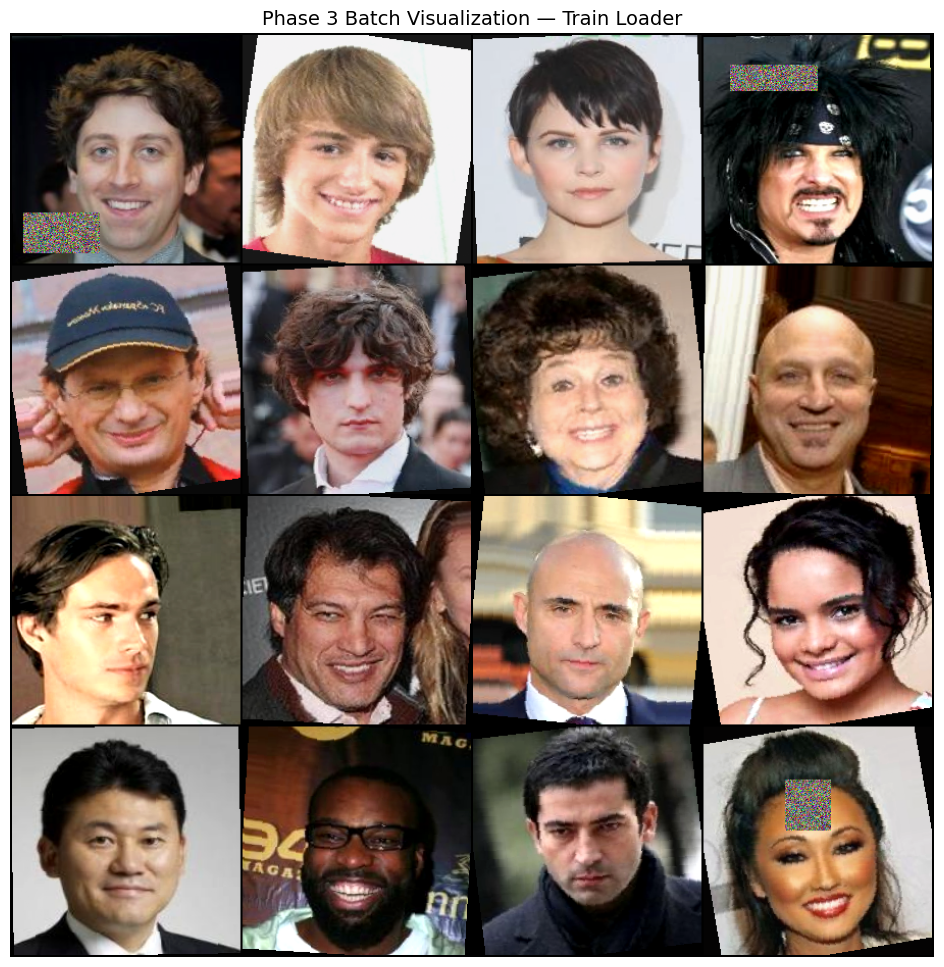


First 16 batch labels:
------------------------------------------------------------------------------------------
00 | 027555.jpg | Bags=1 Chubby=0 DChin=1 Gender=M
01 | 155814.jpg | Bags=1 Chubby=0 DChin=0 Gender=M
02 | 123449.jpg | Bags=0 Chubby=0 DChin=0 Gender=F
03 | 104606.jpg | Bags=0 Chubby=1 DChin=1 Gender=M
04 | 090378.jpg | Bags=1 Chubby=0 DChin=0 Gender=M
05 | 150446.jpg | Bags=1 Chubby=0 DChin=0 Gender=M
06 | 067402.jpg | Bags=1 Chubby=0 DChin=1 Gender=F
07 | 124073.jpg | Bags=1 Chubby=1 DChin=1 Gender=M
08 | 099284.jpg | Bags=1 Chubby=0 DChin=0 Gender=M
09 | 029260.jpg | Bags=1 Chubby=0 DChin=1 Gender=M
10 | 008666.jpg | Bags=1 Chubby=1 DChin=0 Gender=M
11 | 157137.jpg | Bags=1 Chubby=0 DChin=0 Gender=F
12 | 049102.jpg | Bags=1 Chubby=1 DChin=0 Gender=M
13 | 000300.jpg | Bags=0 Chubby=1 DChin=1 Gender=M
14 | 006696.jpg | Bags=1 Chubby=0 DChin=0 Gender=M
15 | 162557.jpg | Bags=0 Chubby=1 DChin=1 Gender=F

Saved batch visualization: /kaggle/working/phase3_batch_visualizatio

In [14]:
# ============================================================
# PHASE 3 — CELL 10: VISUALIZE TRAINING BATCH
# ============================================================

print("=" * 70)
print("VISUALIZING ONE TRAINING BATCH")
print("=" * 70)

# ImageNet unnormalize
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

batch = next(iter(train_loader))

images = batch["image"][:16].cpu()
targets = batch["targets"][:16].cpu()
genders = batch["gender"][:16].cpu()
image_ids = batch["image_id"][:16]

# Unnormalize
images_vis = images * std + mean
images_vis = torch.clamp(images_vis, 0, 1)

grid = make_grid(images_vis, nrow=4, padding=2)

plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Phase 3 Batch Visualization — Train Loader", fontsize=14)
plt.show()

print("\nFirst 16 batch labels:")
print("-" * 90)

for i in range(16):
    bags, chubby, dchin = targets[i].tolist()
    gender = "M" if genders[i].item() == 1 else "F"
    print(
        f"{i:02d} | {image_ids[i]} | "
        f"Bags={int(bags)} Chubby={int(chubby)} DChin={int(dchin)} "
        f"Gender={gender}"
    )

# Save figure
fig_path = WORKING_DIR / "phase3_batch_visualization.png"

plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Phase 3 Batch Visualization — Train Loader", fontsize=14)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.close()

print(f"\nSaved batch visualization: {fig_path}")

In [15]:
# ============================================================
# PHASE 3 — CELL 11: SAVE PHASE 3 SUMMARY
# ============================================================

print("=" * 70)
print("SAVING PHASE 3 SUMMARY")
print("=" * 70)

phase3_summary = {
    "phase": "Phase 3 - Dataset and DataLoader",
    "status": "complete",
    "seed": SEED,
    "paths": {
        "celeba_img_dir": str(IMG_DIR),
        "phase12_dir": str(PHASE12_DIR),
        "manifest_path": str(MANIFEST_PATH),
        "mediapipe_feature_dir": str(MP_FEATURE_DIR),
        "dataset_module": str(DATASET_MODULE_PATH),
    },
    "dataset_sizes": {
        "train": int(len(train_ds)),
        "val": int(len(val_ds)),
        "test": int(len(test_ds)),
        "total": int(len(train_ds) + len(val_ds) + len(test_ds)),
    },
    "config": {
        "image_size": IMAGE_SIZE,
        "mp_dim": MP_DIM,
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "weighted_sampler": True,
        "pin_memory": bool(PIN_MEMORY),
    },
    "target_attrs": TARGET_ATTRS,
    "pos_weights_bce": {
        k: float(v) for k, v in pos_weights_dict.items()
    },
    "train_positive_rates_raw": {
        attr: float((train_df[attr] == 1).mean())
        for attr in TARGET_ATTRS
    },
    "train_positive_rates_sampled_estimate": {
        attr: float(rate.item())
        for attr, rate in zip(TARGET_ATTRS, sampled_rates)
    },
    "mediapipe_success_rate": float(
        manifest["mediapipe_success"].mean()
    ),
}

PHASE3_SUMMARY_PATH = WORKING_DIR / "phase3_summary.json"

with open(PHASE3_SUMMARY_PATH, "w") as f:
    json.dump(phase3_summary, f, indent=2)

print(f"Saved: {PHASE3_SUMMARY_PATH}")

print("\nSummary:")
print(json.dumps(phase3_summary, indent=2)[:3000])

print("\nPhase 3 complete ✓")

SAVING PHASE 3 SUMMARY
Saved: /kaggle/working/phase3_summary.json

Summary:
{
  "phase": "Phase 3 - Dataset and DataLoader",
  "status": "complete",
  "seed": 42,
  "paths": {
    "celeba_img_dir": "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba",
    "phase12_dir": "/kaggle/working/phase12_data",
    "manifest_path": "/kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared/celeba_phase12_manifest_code/phase3_manifest.csv",
    "mediapipe_feature_dir": "/kaggle/working/phase12_data/mediapipe_features",
    "dataset_module": "/kaggle/working/src/celeba_phase3_dataset.py"
  },
  "dataset_sizes": {
    "train": 80280,
    "val": 9694,
    "test": 10026,
    "total": 100000
  },
  "config": {
    "image_size": 224,
    "mp_dim": 18,
    "batch_size": 32,
    "num_workers": 2,
    "weighted_sampler": true,
    "pin_memory": true
  },
  "target_attrs": [
    "Bags_Under_Eyes",
    "Chubby",
    "Double_Chin"
  ],
  "pos_weights_bce": {
    "Bags_U

In [16]:
# ============================================================
# PHASE 3 — CELL 12: FINAL HANDOFF REPORT
# ============================================================

print("=" * 75)
print("PHASE 3 COMPLETE — HANDOFF TO PHASE 4")
print("=" * 75)

print(f"""
DATA READY
────────────────────────────────────────────────────────────
Total samples        : {len(manifest):,}
Train samples        : {len(train_ds):,}
Val samples          : {len(val_ds):,}
Test samples         : {len(test_ds):,}

IMAGE INPUT
────────────────────────────────────────────────────────────
Image size           : {IMAGE_SIZE} x {IMAGE_SIZE}
Image tensor shape   : [B, 3, {IMAGE_SIZE}, {IMAGE_SIZE}]
Normalization        : ImageNet mean/std

MEDIAPIPE INPUT
────────────────────────────────────────────────────────────
MP feature dimension : {MP_DIM}
MP tensor shape      : [B, {MP_DIM}]
MP success rate      : {manifest['mediapipe_success'].mean()*100:.2f}%

TARGETS
────────────────────────────────────────────────────────────
Target tensor shape  : [B, 3]
Target order         : {TARGET_ATTRS}
Encoding             : positive=1.0, negative=0.0

Gender aux encoding  : female=0, male=1

DATALOADERS
────────────────────────────────────────────────────────────
Batch size           : {BATCH_SIZE}
Train batches        : {len(train_loader):,}
Val batches          : {len(val_loader):,}
Test batches         : {len(test_loader):,}
Weighted sampler     : enabled for train_loader

BCE POS_WEIGHTS
────────────────────────────────────────────────────────────
Bags_Under_Eyes      : {float(pos_weights_dict['Bags_Under_Eyes']):.4f}
Chubby               : {float(pos_weights_dict['Chubby']):.4f}
Double_Chin          : {float(pos_weights_dict['Double_Chin']):.4f}

OUTPUT FILES
────────────────────────────────────────────────────────────
Dataset module       : {DATASET_MODULE_PATH}
Summary JSON         : {PHASE3_SUMMARY_PATH}
Batch visualization  : {WORKING_DIR / 'phase3_batch_visualization.png'}

NEXT PHASE
────────────────────────────────────────────────────────────
Phase 4: Model Architectures
  1. Switch Kaggle accelerator to GPU T4 x2
  2. Install/import timm
  3. Build:
       - Swin-Small + MediaPipe MLP fusion
       - ConvNeXt-Base + MediaPipe MLP fusion
       - EfficientNetV2-M + MediaPipe MLP fusion
  4. Run forward-pass test on one batch from train_loader
""")

print("=" * 75)

PHASE 3 COMPLETE — HANDOFF TO PHASE 4

DATA READY
────────────────────────────────────────────────────────────
Total samples        : 100,000
Train samples        : 80,280
Val samples          : 9,694
Test samples         : 10,026

IMAGE INPUT
────────────────────────────────────────────────────────────
Image size           : 224 x 224
Image tensor shape   : [B, 3, 224, 224]
Normalization        : ImageNet mean/std

MEDIAPIPE INPUT
────────────────────────────────────────────────────────────
MP feature dimension : 18
MP tensor shape      : [B, 18]
MP success rate      : 99.67%

TARGETS
────────────────────────────────────────────────────────────
Target tensor shape  : [B, 3]
Target order         : ['Bags_Under_Eyes', 'Chubby', 'Double_Chin']
Encoding             : positive=1.0, negative=0.0

Gender aux encoding  : female=0, male=1

DATALOADERS
────────────────────────────────────────────────────────────
Batch size           : 32
Train batches        : 2,508
Val batches          : 303
T

# phase4

In [3]:
# ============================================================
# PHASE 4 — CELL 33: GPU SETUP & INSTALL DEPENDENCIES
# Run this after switching to GPU T4 x2
# ============================================================

import os
import sys
import subprocess
from pathlib import Path

# Suppress warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("=" * 70)
print("PHASE 4: MODEL ARCHITECTURE & TRAINING")
print("=" * 70)

# Install timm + torchmetrics
print("\nInstalling timm & torchmetrics...")
result = subprocess.run(
    ["pip", "install", "timm", "torchmetrics", "-q", "--no-warn-script-location"],
    capture_output=True, text=True
)
print(f"  pip exit code: {result.returncode}")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
import timm
import numpy as np
import pandas as pd
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nPyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device      : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"CUDA version    : {torch.version.cuda}")
else:
    raise RuntimeError("GPU NOT AVAILABLE. Switch to GPU T4 x2 in Kaggle Settings.")

# Working dirs
WORKING_DIR = Path("/kaggle/working")
WORK_SRC    = WORKING_DIR / "src"
WORK_SRC.mkdir(parents=True, exist_ok=True)
CKPT_DIR    = WORKING_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

if str(WORK_SRC) not in sys.path:
    sys.path.insert(0, str(WORK_SRC))

print(f"\nWorking dir     : {WORKING_DIR}")
print(f"Checkpoints dir : {CKPT_DIR}")
print(f"src dir         : {WORK_SRC}")
print("\nCell 33 complete ✓")

PHASE 4: MODEL ARCHITECTURE & TRAINING

Installing timm & torchmetrics...
  pip exit code: 0

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU device      : Tesla T4
GPU memory      : 14.6 GB
CUDA version    : 12.8

Working dir     : /kaggle/working
Checkpoints dir : /kaggle/working/checkpoints
src dir         : /kaggle/working/src

Cell 33 complete ✓


In [4]:
# ============================================================
# PHASE 4 — CELL 34: FAST STATE RECOVERY
# Rebuilds dataloaders + manifest from Kaggle input dataset
# Runs in ~60 seconds. Safe to rerun after every restart.
# ============================================================

import json
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as T

print("=" * 70)
print("PHASE 3 STATE RECOVERY")
print("=" * 70)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── 1. Locate input datasets ─────────────────────────────────
KAGGLE_INPUT = Path("/kaggle/input")

CELEBA_DIR = Path("/kaggle/input/datasets/jessicali9530/celeba-dataset")
PREPARED_DIR = None

for name in ["datasets/kishlaytejeswi/celeba-phase12-prepared", 
             "datasets/kishlaytejeswi/celeba-phase-12-prepared",
             "datasets/kishlaytejeswi/celeba-phase1-phase2-prepared"]:
    if (KAGGLE_INPUT / name).exists():
        PREPARED_DIR = KAGGLE_INPUT / name
        break

if PREPARED_DIR is None:
    # Search deeper
    for p in KAGGLE_INPUT.rglob("phase3_manifest.csv"):
        PREPARED_DIR = p.parent.parent  # go up to dataset root
        break

assert PREPARED_DIR is not None, "Prepared dataset not found. Add celeba-phase12-prepared to Inputs."

print(f"Prepared dataset: {PREPARED_DIR}")

# ── 2. Locate image dir ──────────────────────────────────────
IMG_DIR = None
for d in [CELEBA_DIR / "img_align_celeba" / "img_align_celeba",
          CELEBA_DIR / "img_align_celeba"]:
    if d.exists() and len(list(d.glob("*.jpg"))) > 0:
        IMG_DIR = d
        break
assert IMG_DIR is not None, "CelebA image dir not found"

# ── 3. Locate manifest & stats ───────────────────────────────
manifest_candidates = list(PREPARED_DIR.rglob("phase3_manifest.csv"))
if len(manifest_candidates) == 0:
    manifest_candidates = list(PREPARED_DIR.rglob("manifest_with_mp.csv"))

MANIFEST_PATH = manifest_candidates[0]
STATS_PATH = list(PREPARED_DIR.rglob("dataset_stats.json"))[0]

print(f"Manifest : {MANIFEST_PATH}")
print(f"Stats    : {STATS_PATH}")

# ── 4. Load manifest ─────────────────────────────────────────
manifest = pd.read_csv(MANIFEST_PATH)
manifest["img_path"] = manifest["image_id"].apply(lambda x: str(IMG_DIR / x))

# Build mp_path from auto-unzipped feature folders
feature_dirs = [d for d in PREPARED_DIR.rglob("mediapipe_features") 
                if d.is_dir() and len(list(d.glob("*.npy"))) > 1000]

mp_map = {}
for d in feature_dirs:
    for f in d.glob("*.npy"):
        mp_map[f.name] = str(f)

def get_mp_path(image_id):
    fname = Path(image_id).stem + ".npy"
    return mp_map.get(fname, "")

manifest["mp_path"] = manifest["image_id"].apply(get_mp_path)

if "mediapipe_success" not in manifest.columns:
    def check_success(p):
        if not p: return 0
        try: return int(np.load(p).sum() != 0)
        except: return 0
    manifest["mediapipe_success"] = manifest["mp_path"].apply(check_success)

print(f"\nManifest loaded : {len(manifest):,} rows")
print(f"MP matched      : {(manifest['mp_path'] != '').sum():,}")
print(f"MP success      : {manifest['mediapipe_success'].mean()*100:.2f}%")

# ── 5. Load stats ────────────────────────────────────────────
with open(STATS_PATH) as f:
    dataset_stats = json.load(f)

pos_weights_dict = dataset_stats.get("pos_weights_bce", {})
if not pos_weights_dict:
    train_tmp = manifest[manifest["split"] == "train"]
    pos_weights_dict = {}
    for col in ["Bags_Under_Eyes", "Chubby", "Double_Chin"]:
        n_pos = (train_tmp[col] == 1).sum()
        n_neg = (train_tmp[col] == -1).sum()
        pos_weights_dict[col] = float(n_neg / max(n_pos, 1))

POS_WEIGHTS_TENSOR = torch.tensor([
    float(pos_weights_dict["Bags_Under_Eyes"]),
    float(pos_weights_dict["Chubby"]),
    float(pos_weights_dict["Double_Chin"]),
], dtype=torch.float32)

print(f"\nPos weights tensor: {POS_WEIGHTS_TENSOR}")

# ── 6. Recreate Dataset class inline (no file dependency) ────
TARGET_ATTRS = ["Bags_Under_Eyes", "Chubby", "Double_Chin"]

class CelebAFaceAttrDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["img_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        
        # MP features
        mp_path = row["mp_path"]
        if mp_path and Path(mp_path).exists():
            mp_vec = np.load(mp_path).astype(np.float32)
            if mp_vec.shape != (18,):
                mp_vec = np.zeros(18, dtype=np.float32)
        else:
            mp_vec = np.zeros(18, dtype=np.float32)
        mp_vec = np.nan_to_num(mp_vec, nan=0.0, posinf=0.0, neginf=0.0)
        
        mp_success = float(row.get("mediapipe_success", 0))
        if mp_success == 0:
            mp_vec[:] = 0.0
        
        targets = np.array([
            1.0 if int(row[a]) == 1 else 0.0 
            for a in TARGET_ATTRS
        ], dtype=np.float32)
        
        gender = 1 if int(row["gender"]) == 1 else 0
        
        return {
            "image": img,
            "mp_features": torch.tensor(mp_vec, dtype=torch.float32),
            "mp_success": torch.tensor(mp_success, dtype=torch.float32),
            "targets": torch.tensor(targets, dtype=torch.float32),
            "gender": torch.tensor(gender, dtype=torch.long),
            "weight": torch.tensor(float(row["sample_weight"]), dtype=torch.float32),
            "image_id": row["image_id"],
        }

# ── 7. Transforms ────────────────────────────────────────────
IMAGE_SIZE = 224

train_tfms = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomGrayscale(p=0.03),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

eval_tfms = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

# ── 8. Datasets ──────────────────────────────────────────────
train_df = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_df   = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_df  = manifest[manifest["split"] == "test"].reset_index(drop=True)

train_ds = CelebAFaceAttrDataset(train_df, train_tfms)
val_ds   = CelebAFaceAttrDataset(val_df, eval_tfms)
test_ds  = CelebAFaceAttrDataset(test_df, eval_tfms)

print(f"\nDatasets created:")
print(f"  Train: {len(train_ds):,}")
print(f"  Val  : {len(val_ds):,}")
print(f"  Test : {len(test_ds):,}")

# ── 9. DataLoaders ───────────────────────────────────────────
BATCH_SIZE = 32
NUM_WORKERS = 2

train_weights = torch.DoubleTensor(train_df["sample_weight"].values)
train_sampler = WeightedRandomSampler(
    weights=train_weights, num_samples=len(train_weights), replacement=True
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
    persistent_workers=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
    persistent_workers=True
)

print(f"\nDataLoaders ready:")
print(f"  Train batches: {len(train_loader):,}")
print(f"  Val batches  : {len(val_loader):,}")
print(f"  Test batches : {len(test_loader):,}")

# ── 10. Verify one batch ─────────────────────────────────────
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  image       : {batch['image'].shape}")
print(f"  mp_features : {batch['mp_features'].shape}")
print(f"  targets     : {batch['targets'].shape}")
print(f"  gender      : {batch['gender'].shape}")

print("\nCell 34 complete — State recovered ✓")
print("Ready for model architecture cells.")

PHASE 3 STATE RECOVERY
Prepared dataset: /kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared
Manifest : /kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared/celeba_phase12_manifest_code/phase3_manifest.csv
Stats    : /kaggle/input/datasets/kishlaytejeswi/celeba-phase12-prepared/dataset_stats.json

Manifest loaded : 100,000 rows
MP matched      : 100,000
MP success      : 99.67%

Pos weights tensor: tensor([1.4123, 7.5504, 9.6036])

Datasets created:
  Train: 80,280
  Val  : 9,694
  Test : 10,026

DataLoaders ready:
  Train batches: 2,508
  Val batches  : 303
  Test batches : 314

Batch shapes:
  image       : torch.Size([32, 3, 224, 224])
  mp_features : torch.Size([32, 18])
  targets     : torch.Size([32, 3])
  gender      : torch.Size([32])

Cell 34 complete — State recovered ✓
Ready for model architecture cells.


In [5]:
# ============================================================
# PHASE 4 — CELL 35: WRITE MODEL ARCHITECTURES TO src/models.py
# ============================================================

models_code = '''
"""
phase4_models.py
────────────────
Three model architectures + shared MediaPipe MLP branch.
All models output logits (not probabilities) for numerical stability.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm


class MediaPipeMLP(nn.Module):
    """2-layer MLP for 18-dim geometric features."""
    def __init__(self, in_dim=18, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(in_dim),
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
    
    def forward(self, x):
        return self.net(x)


class FaceAttrNet(nn.Module):
    """
    Unified face attribute network.
    Backbone (timm) + MediaPipe MLP + Fusion + Heads.
    """
    def __init__(
        self,
        backbone_name: str,
        backbone_dim: int,
        mp_hidden_dim: int = 64,
        fusion_hidden: int = 512,
        dropout: float = 0.4,
        num_attrs: int = 3,
    ):
        super().__init__()
        
        # Visual backbone (feature extractor, no classifier head)
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            num_classes=0,      # remove classification head
            in_chans=3,
        )
        
        # Geometric branch
        self.mp_mlp = MediaPipeMLP(
            in_dim=18, 
            hidden_dim=mp_hidden_dim, 
            dropout=0.2
        )
        
        # Fusion
        fused_dim = backbone_dim + mp_hidden_dim
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, fusion_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        
        # Attribute heads (output LOGITS)
        self.attr_heads = nn.ModuleList([
            nn.Linear(fusion_hidden, 1) for _ in range(num_attrs)
        ])
        
        # Gender auxiliary head (2 classes)
        self.gender_head = nn.Linear(fusion_hidden, 2)
        
    def forward(self, image, mp_features, mp_success=None):
        """
        Args:
            image      : [B, 3, H, W]
            mp_features: [B, 18]
            mp_success : [B] or None
        Returns:
            dict with 'attr_logits', 'gender_logits', 'shared_emb'
        """
        # Visual embedding
        vis_emb = self.backbone(image)  # [B, backbone_dim]
        
        # Geometric embedding
        mp_emb = self.mp_mlp(mp_features)  # [B, mp_hidden_dim]
        
        # Mask failed MediaPipe detections
        if mp_success is not None:
            mp_emb = mp_emb * mp_success.unsqueeze(1)
        
        # Fuse
        fused = torch.cat([vis_emb, mp_emb], dim=1)  # [B, fused_dim]
        shared = self.fusion(fused)                   # [B, fusion_hidden]
        
        # Heads
        attr_logits = torch.cat(
            [head(shared) for head in self.attr_heads], dim=1
        )  # [B, num_attrs]
        
        gender_logits = self.gender_head(shared)  # [B, 2]
        
        return {
            "attr_logits": attr_logits,      # [B, 3]
            "gender_logits": gender_logits,  # [B, 2]
            "shared_emb": shared,            # [B, 512]
        }


# ── Model constructors ───────────────────────────────────────

def build_swin_small(pretrained=True, **kwargs):
    return FaceAttrNet(
        backbone_name="swin_small_patch4_window7_224.ms_in22k",
        backbone_dim=768,
        **kwargs
    )

def build_convnext_base(pretrained=True, **kwargs):
    return FaceAttrNet(
        backbone_name="convnext_base.fb_in22k_ft_in1k",
        backbone_dim=1024,
        **kwargs
    )

def build_effnetv2_m(pretrained=True, **kwargs):
    return FaceAttrNet(
        backbone_name="efficientnetv2_m.in21k_ft_in1k",
        backbone_dim=1280,
        **kwargs
    )
'''

with open(WORK_SRC / "phase4_models.py", "w") as f:
    f.write(models_code)

print("✓ phase4_models.py written")

✓ phase4_models.py written


In [6]:
# ============================================================
# PHASE 4 — CELL 36: WRITE TRAINING UTILITIES
# Checkpointing, Early Stopping, Metrics, Loss, Trainer
# ============================================================

train_utils_code = '''
"""
phase4_train_utils.py
─────────────────────
Loss, metrics, checkpointing, early stopping, trainer.
"""

import os
import json
import time
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score


TARGET_ATTRS = ["Bags_Under_Eyes", "Chubby", "Double_Chin"]


class MultiTaskLoss(nn.Module):
    """
    Weighted BCE for 3 attributes + CE for gender auxiliary.
    """
    def __init__(
        self,
        pos_weights,           # tensor [3]
        lambda_attrs=(1.0, 1.5, 1.5),
        lambda_gender=0.3,
    ):
        super().__init__()
        self.register_buffer("pos_weights", pos_weights)
        self.lambda_attrs = torch.tensor(lambda_attrs)
        self.lambda_gender = lambda_gender
        
    def forward(self, pred, targets, gender):
        """
        pred: dict from model
        targets: [B, 3] float32
        gender: [B] long
        """
        attr_logits = pred["attr_logits"]      # [B, 3]
        gender_logits = pred["gender_logits"]    # [B, 2]
        
        device = attr_logits.device
        
        # Per-attribute BCE with pos_weight
        attr_losses = []
        for i in range(3):
            l = F.binary_cross_entropy_with_logits(
                attr_logits[:, i],
                targets[:, i],
                pos_weight=self.pos_weights[i],
                reduction="mean",
            )
            attr_losses.append(l * self.lambda_attrs[i].to(device))
        
        total_attr_loss = sum(attr_losses)
        
        # Gender auxiliary
        gender_loss = F.cross_entropy(gender_logits, gender, reduction="mean")
        
        total_loss = total_attr_loss + self.lambda_gender * gender_loss
        
        return {
            "loss": total_loss,
            "attr_loss": total_attr_loss,
            "gender_loss": gender_loss,
            "bags_loss": attr_losses[0],
            "chubby_loss": attr_losses[1],
            "dchin_loss": attr_losses[2],
        }


class EarlyStopping:
    def __init__(self, patience=5, mode="max", delta=0.0):
        self.patience = patience
        self.mode = mode
        self.delta = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
        if mode == "max":
            self.is_better = lambda score, best: score > best + delta
        else:
            self.is_better = lambda score, best: score < best - delta
            
    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return
            
        if self.is_better(score, self.best_score):
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


class CheckpointManager:
    def __init__(self, checkpoint_dir):
        self.dir = Path(checkpoint_dir)
        self.dir.mkdir(parents=True, exist_ok=True)
        
    def save(self, epoch, model, optimizer, scheduler, scaler, 
             best_val_map, history, config, is_best=False):
        ckpt = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_val_map": best_val_map,
            "history": history,
            "config": config,
        }
        last_path = self.dir / "checkpoint_last.pt"
        torch.save(ckpt, last_path)
        
        if is_best:
            best_path = self.dir / "checkpoint_best.pt"
            torch.save(ckpt, best_path)
            print(f"  >>> Best model saved (val_mAP={best_val_map:.4f})")
            
    def load(self, model, optimizer, scheduler, scaler, path=None):
        if path is None:
            path = self.dir / "checkpoint_last.pt"
        if not Path(path).exists():
            return None
            
        ckpt = torch.load(path, map_location="cpu")
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        scaler.load_state_dict(ckpt["scaler_state_dict"])
        return ckpt


class Trainer:
    def __init__(self, config, train_loader, val_loader, test_loader, device):
        self.config = config
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.device = device
        
        self.model = config["build_fn"](**config.get("model_kwargs", {})).to(device)
        
        # Optimizer with different LR for backbone vs heads
        backbone_params = []
        head_params = []
        for name, p in self.model.named_parameters():
            if "backbone" in name:
                backbone_params.append(p)
            else:
                head_params.append(p)
        
        self.optimizer = torch.optim.AdamW([
            {"params": backbone_params, "lr": config["lr_backbone"]},
            {"params": head_params, "lr": config["lr_head"]},
        ], weight_decay=config["weight_decay"])
        
        # Scheduler: cosine with warmup
        total_steps = len(train_loader) * config["epochs"]
        warmup_steps = len(train_loader) * config.get("warmup_epochs", 3)
        
        def lr_lambda(step):
            if step < warmup_steps:
                return step / max(1, warmup_steps)
            progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
            return 0.5 * (1 + np.cos(np.pi * progress))
        
        self.scheduler = torch.optim.lr_scheduler.LambdaLR(
            self.optimizer, lr_lambda
        )
        
        self.criterion = MultiTaskLoss(
            pos_weights=config["pos_weights"].to(device),
            lambda_attrs=config.get("lambda_attrs", (1.0, 1.5, 1.5)),
            lambda_gender=config.get("lambda_gender", 0.3),
        )
        
        self.scaler = GradScaler()
        self.ckpt_mgr = CheckpointManager(config["checkpoint_dir"])
        self.early_stop = EarlyStopping(
            patience=config.get("patience", 5), mode="max"
        )
        
        self.best_val_map = 0.0
        self.history = []
        self.start_epoch = 0
        
    def _run_epoch(self, loader, is_train=True):
        if is_train:
            self.model.train()
        else:
            self.model.eval()
            
        all_attr_probs = []
        all_targets = []
        all_genders = []
        total_loss = 0.0
        total_attr_loss = 0.0
        total_gender_loss = 0.0
        n_batches = 0
        
        context = torch.enable_grad if is_train else torch.no_grad
        
        with context():
            for batch in loader:
                images = batch["image"].to(self.device, non_blocking=True)
                mp_feat = batch["mp_features"].to(self.device, non_blocking=True)
                mp_succ = batch["mp_success"].to(self.device, non_blocking=True)
                targets = batch["targets"].to(self.device, non_blocking=True)
                gender = batch["gender"].to(self.device, non_blocking=True)
                
                if is_train:
                    self.optimizer.zero_grad()
                
                with autocast(enabled=True):
                    pred = self.model(images, mp_feat, mp_succ)
                    losses = self.criterion(pred, targets, gender)
                
                loss = losses["loss"]
                
                if is_train:
                    self.scaler.scale(loss).backward()
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                    self.scheduler.step()
                
                total_loss += loss.item()
                total_attr_loss += losses["attr_loss"].item()
                total_gender_loss += losses["gender_loss"].item()
                n_batches += 1
                
                # Collect for metrics (validation/test only)
                if not is_train:
                    probs = torch.sigmoid(pred["attr_logits"]).detach().cpu().numpy()
                    all_attr_probs.append(probs)
                    all_targets.append(targets.cpu().numpy())
                    all_genders.append(gender.cpu().numpy())
        
        avg_loss = total_loss / max(n_batches, 1)
        avg_attr_loss = total_attr_loss / max(n_batches, 1)
        avg_gender_loss = total_gender_loss / max(n_batches, 1)
        
        result = {
            "loss": avg_loss,
            "attr_loss": avg_attr_loss,
            "gender_loss": avg_gender_loss,
        }
        
        if not is_train:
            # Compute sklearn metrics
            y_prob = np.concatenate(all_attr_probs, axis=0)
            y_true = np.concatenate(all_targets, axis=0)
            
            mAPs = []
            AUCs = []
            F1s = []
            
            for i, attr in enumerate(TARGET_ATTRS):
                yt = y_true[:, i]
                yp = y_prob[:, i]
                
                try:
                    auc = roc_auc_score(yt, yp)
                except ValueError:
                    auc = 0.5
                    
                try:
                    ap = average_precision_score(yt, yp)
                except ValueError:
                    ap = 0.0
                
                y_pred = (yp >= 0.5).astype(int)
                f1 = f1_score(yt, y_pred, zero_division=0)
                
                result[f"{attr}_auc"] = auc
                result[f"{attr}_ap"] = ap
                result[f"{attr}_f1"] = f1
                
                AUCs.append(auc)
                APs.append(ap)
                F1s.append(f1)
            
            result["val_mAP"] = np.mean(APs)
            result["val_mean_auc"] = np.mean(AUCs)
            result["val_mean_f1"] = np.mean(F1s)
            
        return result
    
    def train(self, resume=True):
        # Auto-resume if checkpoint exists
        ckpt_path = None
        if resume:
            last_ckpt = Path(self.config["checkpoint_dir"]) / "checkpoint_last.pt"
            if last_ckpt.exists():
                ckpt_path = last_ckpt
                print(f"Auto-resuming from {ckpt_path}")
        
        if ckpt_path:
            ckpt = self.ckpt_mgr.load(
                self.model, self.optimizer, self.scheduler, self.scaler, ckpt_path
            )
            if ckpt:
                self.start_epoch = ckpt["epoch"] + 1
                self.best_val_map = ckpt.get("best_val_map", 0.0)
                self.history = ckpt.get("history", [])
                print(f"Resumed from epoch {ckpt['epoch']}, "
                      f"best val_mAP={self.best_val_map:.4f}")
        
        print(f"\\nTraining {self.config['model_name']} "
              f"from epoch {self.start_epoch} to {self.config['epochs']}")
        print("=" * 60)
        
        for epoch in range(self.start_epoch, self.config["epochs"]):
            t0 = time.time()
            
            train_metrics = self._run_epoch(self.train_loader, is_train=True)
            val_metrics = self._run_epoch(self.val_loader, is_train=False)
            
            epoch_time = time.time() - t0
            
            # Log
            log_line = (
                f"Epoch {epoch:02d}/{self.config['epochs']} | "
                f"Time {epoch_time/60:.1f}m | "
                f"TrainLoss {train_metrics['loss']:.4f} | "
                f"ValLoss {val_metrics['loss']:.4f} | "
                f"Val_mAP {val_metrics['val_mAP']:.4f} | "
                f"BagsAP {val_metrics['Bags_Under_Eyes_ap']:.4f} | "
                f"ChubAP {val_metrics['Chubby_ap']:.4f} | "
                f"DChinAP {val_metrics['Double_Chin_ap']:.4f}"
            )
            print(log_line)
            
            self.history.append({
                "epoch": epoch,
                **{f"train_{k}": v for k, v in train_metrics.items()},
                **{f"val_{k}": v for k, v in val_metrics.items()},
            })
            
            # Save best
            is_best = val_metrics["val_mAP"] > self.best_val_map
            if is_best:
                self.best_val_map = val_metrics["val_mAP"]
            
            # Checkpoint every epoch (lightweight, just state dict)
            self.ckpt_mgr.save(
                epoch, self.model, self.optimizer, self.scheduler,
                self.scaler, self.best_val_map, self.history,
                self.config, is_best=is_best
            )
            
            # Early stopping
            self.early_stop(val_metrics["val_mAP"])
            if self.early_stop.early_stop:
                print(f"\\n>>> Early stopping triggered at epoch {epoch}")
                break
        
        print(f"\\nTraining complete. Best val_mAP: {self.best_val_map:.4f}")
        return self.history
    
    def evaluate_test(self):
        """Run on test set using best checkpoint."""
        best_path = Path(self.config["checkpoint_dir"]) / "checkpoint_best.pt"
        if best_path.exists():
            ckpt = torch.load(best_path, map_location=self.device)
            self.model.load_state_dict(ckpt["model_state_dict"])
            print(f"Loaded best checkpoint from epoch {ckpt['epoch']}")
        
        self.model.eval()
        metrics = self._run_epoch(self.test_loader, is_train=False)
        
        print("\\nTest Set Results:")
        print("-" * 40)
        for attr in TARGET_ATTRS:
            print(f"  {attr:<20s} AUC={metrics[f'{attr}_auc']:.4f}  "
                  f"AP={metrics[f'{attr}_ap']:.4f}  "
                  f"F1={metrics[f'{attr}_f1']:.4f}")
        print(f"  {'mAP':<20s} {metrics['val_mAP']:.4f}")
        print(f"  {'Mean AUC':<20s} {metrics['val_mean_auc']:.4f}")
        return metrics
'''

with open(WORK_SRC / "phase4_train_utils.py", "w") as f:
    f.write(train_utils_code)

print("✓ phase4_train_utils.py written")
print("\nImports ready. Next cells train one model at a time.")

✓ phase4_train_utils.py written

Imports ready. Next cells train one model at a time.


In [7]:
# ============================================================
# FIX CELL: Correct variable name in phase4_train_utils.py
# ============================================================

from pathlib import Path

utils_path = Path("/kaggle/working/src/phase4_train_utils.py")

# Read → fix → write back
code = utils_path.read_text()

# Change mAPs = []  to  APs = []  (to match the append lines below)
code = code.replace("mAPs = []", "APs = []")

# Safety: ensure no leftover mAPs references
code = code.replace("np.mean(mAPs)", "np.mean(APs)")

utils_path.write_text(code)

# Clear Python import cache so the fix is loaded
import sys
if "phase4_train_utils" in sys.modules:
    del sys.modules["phase4_train_utils"]

print("✓ phase4_train_utils.py fixed")
print("  Changed: mAPs → APs")
print("  Now run Cell 37 below.")

✓ phase4_train_utils.py fixed
  Changed: mAPs → APs
  Now run Cell 37 below.


In [10]:
# ============================================================
# PHASE 4 — CELL 37: TRAIN MODEL 1 — SWIN-SMALL
# ============================================================
# This cell is fully self-contained. If session dies, rerun
# Cell 33 → 34 → then this cell. It auto-resumes from checkpoint.
# ============================================================

from phase4_models import build_swin_small
from phase4_train_utils import Trainer

print("=" * 70)
print("MODEL 1: SWIN-SMALL TRAINING")
print("=" * 70)

SWIN_CONFIG = {
    "model_name": "swin_small",
    "build_fn": build_swin_small,
    "model_kwargs": {"dropout": 0.4},
    "backbone_dim": 768,
    "lr_backbone": 1e-5,
    "lr_head": 1e-4,
    "weight_decay": 0.05,
    "epochs": 30,
    "patience": 5,
    "warmup_epochs": 3,
    "pos_weights": POS_WEIGHTS_TENSOR,
    "lambda_attrs": (1.0, 1.5, 1.5),
    "lambda_gender": 0.3,
    "checkpoint_dir": str(CKPT_DIR / "swin_small"),
    "batch_size": BATCH_SIZE,
}

# Clear CUDA cache
torch.cuda.empty_cache()

trainer_swin = Trainer(
    config=SWIN_CONFIG,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=DEVICE,
)

# Train (auto-resumes if checkpoint exists)
history_swin = trainer_swin.train(resume=True)

print("\nSwin-Small training complete ✓")
print(f"Best val_mAP: {trainer_swin.best_val_map:.4f}")
print(f"Checkpoint dir: {SWIN_CONFIG['checkpoint_dir']}")

MODEL 1: SWIN-SMALL TRAINING


model.safetensors:   0%|          | 0.00/264M [00:00<?, ?B/s]


Training swin_small from epoch 0 to 30
Epoch 00/30 | Time 15.9m | TrainLoss 4.7985 | ValLoss 2.0680 | Val_mAP 0.7751 | BagsAP 0.8820 | ChubAP 0.7481 | DChinAP 0.6951
  >>> Best model saved (val_mAP=0.7751)
Epoch 01/30 | Time 15.2m | TrainLoss 3.2328 | ValLoss 1.9861 | Val_mAP 0.7987 | BagsAP 0.9011 | ChubAP 0.7667 | DChinAP 0.7282
  >>> Best model saved (val_mAP=0.7987)
Epoch 02/30 | Time 15.2m | TrainLoss 2.9531 | ValLoss 2.0122 | Val_mAP 0.8007 | BagsAP 0.8927 | ChubAP 0.7577 | DChinAP 0.7518
  >>> Best model saved (val_mAP=0.8007)
Epoch 03/30 | Time 15.2m | TrainLoss 2.6838 | ValLoss 1.8270 | Val_mAP 0.8072 | BagsAP 0.8943 | ChubAP 0.7864 | DChinAP 0.7409
  >>> Best model saved (val_mAP=0.8072)
Epoch 04/30 | Time 15.2m | TrainLoss 2.4053 | ValLoss 1.9108 | Val_mAP 0.8032 | BagsAP 0.9016 | ChubAP 0.7771 | DChinAP 0.7307
Epoch 05/30 | Time 15.2m | TrainLoss 2.1670 | ValLoss 2.1227 | Val_mAP 0.7974 | BagsAP 0.9046 | ChubAP 0.7570 | DChinAP 0.7305
Epoch 06/30 | Time 15.2m | TrainLoss 1

In [11]:
# ============================================================
# PHASE 4 — CELL 38: PACKAGE SWIN CHECKPOINT FOR KAGGLE DATASET
# Run this AFTER Swin training finishes and BEFORE you pause.
# This zips the checkpoint so you can save it to a Kaggle Dataset.
# ============================================================

import zipfile
from pathlib import Path

print("=" * 70)
print("PACKAGING SWIN-SMALL CHECKPOINT")
print("=" * 70)

swin_ckpt_dir = CKPT_DIR / "swin_small"
swin_zip = WORKING_DIR / "ckpt_swin_small.zip"

with zipfile.ZipFile(swin_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for f in swin_ckpt_dir.rglob("*"):
        if f.is_file():
            zf.write(f, f.relative_to(CKPT_DIR))

size_mb = swin_zip.stat().st_size / 1024 / 1024
print(f"Created: {swin_zip}")
print(f"Size   : {size_mb:.2f} MB")

print("""
INSTRUCTIONS TO SAVE CHECKPOINT (so you can resume later):
─────────────────────────────────────────────────────────
1. In Kaggle right panel → Output → find ckpt_swin_small.zip
2. Click "Save as Dataset" 
   OR download and upload manually.
3. Recommended: create dataset "celeba-phase4-checkpoints"
   and add this zip to it.

When resuming later:
  - Add "celeba-phase4-checkpoints" to notebook inputs
  - Unzip to /kaggle/working/checkpoints/swin_small/
  - Rerun this cell (37) → it will auto-resume from checkpoint

You can now PAUSE or shutdown. Swin-Small is safe.
─────────────────────────────────────────────────────────
""")

PACKAGING SWIN-SMALL CHECKPOINT
Created: /kaggle/working/ckpt_swin_small.zip
Size   : 1044.71 MB

INSTRUCTIONS TO SAVE CHECKPOINT (so you can resume later):
─────────────────────────────────────────────────────────
1. In Kaggle right panel → Output → find ckpt_swin_small.zip
2. Click "Save as Dataset" 
   OR download and upload manually.
3. Recommended: create dataset "celeba-phase4-checkpoints"
   and add this zip to it.

When resuming later:
  - Add "celeba-phase4-checkpoints" to notebook inputs
  - Unzip to /kaggle/working/checkpoints/swin_small/
  - Rerun this cell (37) → it will auto-resume from checkpoint

You can now PAUSE or shutdown. Swin-Small is safe.
─────────────────────────────────────────────────────────



In [16]:
# ============================================================
# FIX: SPLIT LARGE CHECKPOINT ZIP INTO DOWNLOADABLE CHUNKS
# ============================================================

import os
from pathlib import Path

WORKING_DIR = Path("/kaggle/working")
CKPT_DIR = WORKING_DIR / "checkpoints" / "swin_small"

# Recreate zip if missing
swin_zip = WORKING_DIR / "ckpt_swin_small.zip"
if not swin_zip.exists():
    import zipfile
    print("Recreating ckpt_swin_small.zip...")
    with zipfile.ZipFile(swin_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for f in CKPT_DIR.rglob("*"):
            if f.is_file():
                zf.write(f, f.relative_to(WORKING_DIR / "checkpoints"))
    print(f"Created: {swin_zip}")

# Split into 100MB chunks
CHUNK_SIZE = 100 * 1024 * 1024  # 100 MB

def split_file(filepath, chunk_size):
    filepath = Path(filepath)
    size_mb = filepath.stat().st_size / 1024 / 1024
    print(f"Splitting {filepath.name} ({size_mb:.1f} MB)...")
    
    with open(filepath, "rb") as src:
        chunk_idx = 0
        while True:
            chunk = src.read(chunk_size)
            if not chunk:
                break
            out_path = filepath.parent / f"{filepath.name}.part{chunk_idx:03d}"
            with open(out_path, "wb") as dst:
                dst.write(chunk)
            print(f"  → {out_path.name} ({len(chunk)/1024/1024:.1f} MB)")
            chunk_idx += 1
    
    print(f"Done. {chunk_idx} chunks created.")
    return chunk_idx

n_chunks = split_file(swin_zip, CHUNK_SIZE)

print(f"\nDownload these files from Output panel:")
for i in range(n_chunks):
    part_name = f"ckpt_swin_small.zip.part{i:03d}"
    print(f"  {part_name}")

print("\nTo reassemble locally:")
print("  Linux/Mac: cat ckpt_swin_small.zip.part* > ckpt_swin_small.zip")
print("  Windows: copy /b ckpt_swin_small.zip.part001 + ckpt_swin_small.zip.part002 + ... ckpt_swin_small.zip")

Splitting ckpt_swin_small.zip (1044.7 MB)...
  → ckpt_swin_small.zip.part000 (100.0 MB)
  → ckpt_swin_small.zip.part001 (100.0 MB)
  → ckpt_swin_small.zip.part002 (100.0 MB)
  → ckpt_swin_small.zip.part003 (100.0 MB)
  → ckpt_swin_small.zip.part004 (100.0 MB)
  → ckpt_swin_small.zip.part005 (100.0 MB)
  → ckpt_swin_small.zip.part006 (100.0 MB)
  → ckpt_swin_small.zip.part007 (100.0 MB)
  → ckpt_swin_small.zip.part008 (100.0 MB)
  → ckpt_swin_small.zip.part009 (100.0 MB)
  → ckpt_swin_small.zip.part010 (44.7 MB)
Done. 11 chunks created.

Download these files from Output panel:
  ckpt_swin_small.zip.part000
  ckpt_swin_small.zip.part001
  ckpt_swin_small.zip.part002
  ckpt_swin_small.zip.part003
  ckpt_swin_small.zip.part004
  ckpt_swin_small.zip.part005
  ckpt_swin_small.zip.part006
  ckpt_swin_small.zip.part007
  ckpt_swin_small.zip.part008
  ckpt_swin_small.zip.part009
  ckpt_swin_small.zip.part010

To reassemble locally:
  Linux/Mac: cat ckpt_swin_small.zip.part* > ckpt_swin_small.zi

In [20]:
# ============================================================
# AUTO-UPLOAD CHECKPOINT TO KAGGLE DATASET (FIXED)
# No manual kaggle.json needed — Kaggle notebook auth is used.
# Ensure Internet is ON in Settings.
# ============================================================

import json
import subprocess
import sys
import os
from pathlib import Path
import shutil

print("=" * 70)
print("AUTO-UPLOADING CHECKPOINT TO KAGGLE DATASET")
print("=" * 70)

# ------------------------------------------------------------
# 0. Ensure kaggle CLI is installed
# ------------------------------------------------------------
print("Checking kaggle CLI...")
result = subprocess.run(["kaggle", "--version"], capture_output=True, text=True)
if result.returncode != 0:
    print("Installing kaggle CLI...")
    subprocess.run([sys.executable, "-m", "pip", "install", "kaggle", "-q", "--no-warn-script-location"],
                   check=True)
    print("✓ kaggle installed")

# ------------------------------------------------------------
# 1. Ensure kaggle config dir exists (create empty if needed)
# ------------------------------------------------------------
KAGGLE_DIR = Path("/root/.kaggle")
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)

# Set proper permissions regardless
os.chmod(KAGGLE_DIR, 0o700)

# Try to get username from existing file or env
USERNAME = None
KAGGLE_JSON = KAGGLE_DIR / "kaggle.json"

if KAGGLE_JSON.exists():
    with open(KAGGLE_JSON) as f:
        creds = json.load(f)
    USERNAME = creds.get("username")
    print(f"✓ Found kaggle.json, username: {USERNAME}")
else:
    # In Kaggle notebooks, sometimes env vars exist
    USERNAME = os.environ.get("KAGGLE_USERNAME")
    if USERNAME:
        print(f"✓ Found KAGGLE_USERNAME env: {USERNAME}")
        # Write kaggle.json so CLI works
        KEY = os.environ.get("KAGGLE_KEY", "placeholder")
        with open(KAGGLE_JSON, "w") as f:
            json.dump({"username": USERNAME, "key": KEY}, f)
        os.chmod(KAGGLE_JSON, 0o600)

# If still no username, we'll try anyway — Kaggle internal auth may work
if not USERNAME:
    print("⚠ No explicit credentials found, but Kaggle notebook auth may still work.")
    print("  Will attempt upload anyway...\n")
    USERNAME = "kishlaytejeswi"  # placeholder for metadata

# ------------------------------------------------------------
# 2. Prepare staging folder
# ------------------------------------------------------------

WORKING_DIR = Path("/kaggle/working")
CKPT_ZIP = WORKING_DIR / "ckpt_swin_small.zip"
CKPT_DIR = WORKING_DIR / "checkpoints" / "swin_small"

UPLOAD_DIR = WORKING_DIR / "dataset_upload_checkpoints"
UPLOAD_DIR.mkdir(parents=True, exist_ok=True)

# Clean old staged files (keep metadata if present)
for item in UPLOAD_DIR.iterdir():
    if item.name == "dataset-metadata.json":
        continue
    if item.is_dir():
        shutil.rmtree(item)
    else:
        item.unlink()

# ------------------------------------------------------------
# 3. Stage checkpoint files
# ------------------------------------------------------------

staged = False

if CKPT_ZIP.exists():
    dst = UPLOAD_DIR / CKPT_ZIP.name
    shutil.copy2(CKPT_ZIP, dst)
    size_mb = dst.stat().st_size / 1024 / 1024
    print(f"✓ Staged zip: {dst.name} ({size_mb:.1f} MB)")
    staged = True
elif CKPT_DIR.exists():
    dst_ckpt = UPLOAD_DIR / "swin_small"
    dst_ckpt.mkdir(exist_ok=True)
    n_files = 0
    for src_file in CKPT_DIR.rglob("*"):
        if src_file.is_file():
            rel = src_file.relative_to(CKPT_DIR)
            dst_file = dst_ckpt / rel
            dst_file.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_file, dst_file)
            n_files += 1
    print(f"✓ Staged checkpoint dir: {dst_ckpt} ({n_files} files)")
    staged = True

if not staged:
    raise FileNotFoundError("No checkpoint zip or dir found to upload.")

# ------------------------------------------------------------
# 4. Create dataset-metadata.json
# ------------------------------------------------------------

# Use a clean slug
DATASET_SLUG = "celeba-phase4-checkpoints"
DATASET_ID = f"{USERNAME}/{DATASET_SLUG}"

metadata = {
    "title": "CelebA Phase 4 Model Checkpoints",
    "id": DATASET_ID,
    "licenses": [{"name": "CC0-1.0"}]
}

with open(UPLOAD_DIR / "dataset-metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\nDataset metadata: {DATASET_ID}")
print("Starting upload... This takes ~3-8 minutes for 1.1 GB.\n")

# ------------------------------------------------------------
# 5. Upload function with retries
# ------------------------------------------------------------

def run_cmd(cmd, desc):
    print(f"$ {' '.join(cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.stdout:
        print("stdout:", result.stdout)
    if result.stderr:
        print("stderr:", result.stderr)
    return result

# Try create first
result = run_cmd(
    ["kaggle", "datasets", "create", "-p", str(UPLOAD_DIR), "--dir-mode", "zip"],
    "Creating new dataset..."
)

# If dataset exists, create version
if result.returncode != 0:
    err = (result.stdout + result.stderr).lower()
    if any(x in err for x in ["already exist", "already exists", "use kaggle datasets version", "conflict"]):
        print("\nDataset exists → creating new version...")
        result = run_cmd(
            ["kaggle", "datasets", "version", "-p", str(UPLOAD_DIR), 
             "-m", "Add Swin-Small checkpoint", "--dir-mode", "zip"],
            "Creating new version..."
        )
    else:
        print("\n✗ Upload failed. Possible reasons:")
        print("  1. Internet is OFF → turn ON in Settings (right panel)")
        print("  2. Kaggle API auth issue")
        print("  3. Dataset name conflict with another user")
        print("\nFallback: Download kaggle.json from")
        print("  https://www.kaggle.com/settings/account")
        print("  Upload it to /root/.kaggle/kaggle.json and retry.")

if result.returncode == 0:
    print("\n" + "=" * 70)
    print("✓ SUCCESS — Checkpoint uploaded to Kaggle Dataset!")
    print("=" * 70)
    print(f"\nDataset URL:")
    print(f"https://www.kaggle.com/datasets/{DATASET_ID}")
    print(f"\nFor future notebooks, add this dataset:")
    print(f"  Input → Add Data → Search: '{DATASET_SLUG}'")
else:
    print("\n✗ Upload did not complete successfully.")
    print("See error messages above.")

AUTO-UPLOADING CHECKPOINT TO KAGGLE DATASET
Checking kaggle CLI...
⚠ No explicit credentials found, but Kaggle notebook auth may still work.
  Will attempt upload anyway...

✓ Staged zip: ckpt_swin_small.zip (1044.7 MB)

Dataset metadata: kishlaytejeswi/celeba-phase4-checkpoints
Starting upload... This takes ~3-8 minutes for 1.1 GB.

$ kaggle datasets create -p /kaggle/working/dataset_upload_checkpoints --dir-mode zip
stdout: Warning: Looks like you're using an outdated `kaggle` version (installed: 2.0.1), please consider upgrading to the latest version (2.2.2)
Starting upload for file ckpt_swin_small.zip
Upload successful: ckpt_swin_small.zip (1GB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/kishlaytejeswi/celeba-phase4-checkpoints

stderr: 
  0%|          | 0.00/1.02G [00:00<?, ?B/s]
  1%|▏         | 15.0M/1.02G [00:00<00:06, 155MB/s]
  3%|▎         | 32.2M/1.02G [00:00<00:06, 166MB/s]
  5%|▍         | 48.0M/1.02G [00:00<00:06, 160M

In [21]:
# ============================================================
# PHASE 4 — CELL 39: OVERNIGHT SETUP
# Keep-alive thread + Auto-upload utility + Pre-zip existing ckpts
# ============================================================

import os
import sys
import json
import time
import shutil
import zipfile
import threading
import subprocess
from pathlib import Path

print("=" * 70)
print("OVERNIGHT SETUP: Keep-Alive + Auto-Upload Utility")
print("=" * 70)

# ------------------------------------------------------------
# 1. Ensure kaggle CLI installed
# ------------------------------------------------------------
print("Ensuring kaggle CLI...")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "kaggle", "-q", "--no-warn-script-location"
])
print("✓ kaggle CLI ready")

# ------------------------------------------------------------
# 2. Patch train utils if needed (safety)
# ------------------------------------------------------------
utils_path = Path("/kaggle/working/src/phase4_train_utils.py")
if utils_path.exists():
    code = utils_path.read_text()
    if "mAPs = []" in code:
        code = code.replace("mAPs = []", "APs = []")
        code = code.replace("np.mean(mAPs)", "np.mean(APs)")
        utils_path.write_text(code)
        print("✓ Patched phase4_train_utils.py (mAPs→APs)")
        if "phase4_train_utils" in sys.modules:
            del sys.modules["phase4_train_utils"]

# ------------------------------------------------------------
# 3. Pre-zip any existing checkpoint dirs (e.g. Swin)
# ------------------------------------------------------------
WORKING_DIR = Path("/kaggle/working")
CKPT_DIR = WORKING_DIR / "checkpoints"

if CKPT_DIR.exists():
    for ckpt_subdir in sorted(CKPT_DIR.iterdir()):
        if ckpt_subdir.is_dir():
            zip_name = f"ckpt_{ckpt_subdir.name}.zip"
            zip_path = WORKING_DIR / zip_name
            if not zip_path.exists():
                print(f"Zipping existing checkpoint: {ckpt_subdir.name} ...")
                with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
                    for f in ckpt_subdir.rglob("*"):
                        if f.is_file():
                            zf.write(f, f.relative_to(CKPT_DIR))
                size_gb = zip_path.stat().st_size / 1024**3
                print(f"  → {zip_name} ({size_gb:.2f} GB)")
            else:
                print(f"  Found existing: {zip_name}")

# ------------------------------------------------------------
# 4. Auto-upload function (accumulates ALL ckpt_*.zip)
# ------------------------------------------------------------
USERNAME = "kishlaytejeswi"
DATASET_SLUG = "celeba-phase4-checkpoints"

def auto_upload_all_checkpoints():
    """
    Zips nothing new here — just uploads ALL ckpt_*.zip already in working dir.
    Creates dataset if missing, otherwise creates a new version.
    """
    import glob
    
    working = Path("/kaggle/working")
    staging = working / "_auto_upload_staging"
    
    # Clean staging
    if staging.exists():
        shutil.rmtree(staging)
    staging.mkdir(parents=True, exist_ok=True)
    
    # Gather all checkpoint zips
    ckpt_zips = sorted(working.glob("ckpt_*.zip"))
    if not ckpt_zips:
        print("[UPLOAD] No ckpt_*.zip files found. Skipping.")
        return False
    
    print(f"\n[UPLOAD] Staging {len(ckpt_zips)} checkpoint zip(s):")
    total_gb = 0
    for z in ckpt_zips:
        gb = z.stat().st_size / 1024**3
        total_gb += gb
        print(f"  {z.name} ({gb:.2f} GB)")
        shutil.copy2(z, staging / z.name)
    print(f"  Total: {total_gb:.2f} GB")
    
    # Metadata
    meta = {
        "title": "CelebA Phase 4 Checkpoints",
        "id": f"{USERNAME}/{DATASET_SLUG}",
        "licenses": [{"name": "CC0-1.0"}]
    }
    with open(staging / "dataset-metadata.json", "w") as f:
        json.dump(meta, f, indent=2)
    
    # Auth from Kaggle notebook environment
    kaggle_dir = Path("/root/.kaggle")
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kj = kaggle_dir / "kaggle.json"
    if not kj.exists():
        uname = os.environ.get("KAGGLE_USERNAME")
        key = os.environ.get("KAGGLE_KEY")
        if uname and key:
            with open(kj, "w") as f:
                json.dump({"username": uname, "key": key}, f)
            os.chmod(kj, 0o600)
            print("[UPLOAD] Wrote kaggle.json from environment")
    
    # Execute upload
    print(f"\n[UPLOAD] Uploading to {USERNAME}/{DATASET_SLUG} ...")
    print("         This can take 5-20 minutes. Do not interrupt.\n")
    
    try:
        # Try create
        res = subprocess.run(
            ["kaggle", "datasets", "create", "-p", str(staging)],
            capture_output=True, text=True, timeout=1800
        )
        
        if res.returncode != 0:
            err = (res.stdout + res.stderr).lower()
            if any(x in err for x in ["already exists", "already exist", "use kaggle datasets version"]):
                print("[UPLOAD] Dataset exists → creating new version...")
                res = subprocess.run(
                    ["kaggle", "datasets", "version", "-p", str(staging),
                     "-m", f"Auto-upload {time.strftime('%Y-%m-%d %H:%M')}"],
                    capture_output=True, text=True, timeout=1800
                )
            else:
                print("[UPLOAD] Create failed:", res.stderr[-500:])
        
        if res.returncode == 0:
            print(f"\n{'='*70}")
            print(f"✓ UPLOAD SUCCESS")
            print(f"  https://www.kaggle.com/datasets/{USERNAME}/{DATASET_SLUG}")
            print(f"{'='*70}")
            # Clean staging to free disk
            shutil.rmtree(staging)
            return True
        else:
            print("\n[UPLOAD] FAILED")
            print("stderr tail:", res.stderr[-500:])
            return False
            
    except subprocess.TimeoutExpired:
        print("[UPLOAD] TIMEOUT after 30 minutes. Check internet connection.")
        return False

# ------------------------------------------------------------
# 5. Keep-alive thread (prevents Kaggle idle timeout)
# ------------------------------------------------------------
def _keep_alive():
    while True:
        time.sleep(180)  # every 3 minutes
        print(f"\n[KEEP-ALIVE {time.strftime('%H:%M:%S')}] Session active — training in progress...")

threading.Thread(target=_keep_alive, daemon=True).start()
print("✓ Keep-alive thread started (prints every 3 min)")

# ------------------------------------------------------------
# 6. Initial upload of any existing checkpoints (Swin, etc.)
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("UPLOADING ANY PRE-EXISTING CHECKPOINTS BEFORE TRAINING")
print("=" * 70)
auto_upload_all_checkpoints()

print("\nCell 39 complete. Ready for overnight training.")
print("Run Cell 40 (ConvNeXt) next. It will train, zip, and upload automatically.")

OVERNIGHT SETUP: Keep-Alive + Auto-Upload Utility
Ensuring kaggle CLI...
✓ kaggle CLI ready
Zipping existing checkpoint: convnext_base ...
  → ckpt_convnext_base.zip (1.83 GB)
  Found existing: ckpt_swin_small.zip
✓ Keep-alive thread started (prints every 3 min)

UPLOADING ANY PRE-EXISTING CHECKPOINTS BEFORE TRAINING

[UPLOAD] Staging 2 checkpoint zip(s):
  ckpt_convnext_base.zip (1.83 GB)
  ckpt_swin_small.zip (1.02 GB)
  Total: 2.85 GB

[UPLOAD] Uploading to kishlaytejeswi/celeba-phase4-checkpoints ...
         This can take 5-20 minutes. Do not interrupt.


✓ UPLOAD SUCCESS
  https://www.kaggle.com/datasets/kishlaytejeswi/celeba-phase4-checkpoints

Cell 39 complete. Ready for overnight training.
Run Cell 40 (ConvNeXt) next. It will train, zip, and upload automatically.


In [8]:
# ============================================================
# FIX CELL: Patch torch.load weights_only for PyTorch 2.6+
# ============================================================

from pathlib import Path
import sys

utils_path = Path("/kaggle/working/src/phase4_train_utils.py")

# Read
code = utils_path.read_text()

# Replace all torch.load calls to add weights_only=False
# Pattern 1: torch.load(path, map_location="cpu")
code = code.replace(
    'torch.load(path, map_location="cpu")',
    'torch.load(path, map_location="cpu", weights_only=False)'
)

# Pattern 2: torch.load(best_path, map_location=self.device) in evaluate_test
code = code.replace(
    'torch.load(best_path, map_location=self.device)',
    'torch.load(best_path, map_location=self.device, weights_only=False)'
)

# Write back
utils_path.write_text(code)

# Clear module cache
if "phase4_train_utils" in sys.modules:
    del sys.modules["phase4_train_utils"]

print("✓ Patched phase4_train_utils.py")
print("  torch.load(..., weights_only=False) added")
print("Rerun Cell 40 (ConvNeXt training) now.")

✓ Patched phase4_train_utils.py
  torch.load(..., weights_only=False) added
Rerun Cell 40 (ConvNeXt training) now.


In [9]:
# ============================================================
# FIX CELL: RECREATE DATALOADERS (Fix worker crash)
# Run this before Cell 40, then rerun Cell 40.
# ============================================================

import gc
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

print("=" * 70)
print("RECREATING DATALOADERS (Worker Crash Fix)")
print("=" * 70)

# Delete old loader references to kill stale worker processes
for var in ["train_loader", "val_loader", "test_loader", 
            "train_sampler", "train_weights"]:
    if var in globals():
        del globals()[var]

gc.collect()
torch.cuda.empty_cache()

# Recreate datasets fresh (fast, just wrappers)
train_df = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_df   = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_df  = manifest[manifest["split"] == "test"].reset_index(drop=True)

train_ds = CelebAFaceAttrDataset(train_df, train_tfms)
val_ds   = CelebAFaceAttrDataset(val_df, eval_tfms)
test_ds  = CelebAFaceAttrDataset(test_df, eval_tfms)

print(f"Datasets recreated: Train={len(train_ds):,} Val={len(val_ds):,} Test={len(test_ds):,}")

# Recreate loaders with persistent_workers=False for stability
BATCH_SIZE = 32
NUM_WORKERS = 2

train_weights = torch.DoubleTensor(train_df["sample_weight"].values)
train_sampler = WeightedRandomSampler(
    weights=train_weights, num_samples=len(train_weights), replacement=True
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=False   # <-- FIX: was True, now False
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
    persistent_workers=False
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
    persistent_workers=False
)

print(f"DataLoaders recreated:")
print(f"  Train batches: {len(train_loader):,}")
print(f"  Val batches  : {len(val_loader):,}")
print(f"  Test batches : {len(test_loader):,}")

# Quick sanity check
batch = next(iter(train_loader))
print(f"\nSanity check batch shapes:")
print(f"  image : {batch['image'].shape}")
print(f"  mp    : {batch['mp_features'].shape}")

print("\n✓ DataLoaders fresh and ready. Now rerun Cell 40 (ConvNeXt training).")

RECREATING DATALOADERS (Worker Crash Fix)
Datasets recreated: Train=80,280 Val=9,694 Test=10,026
DataLoaders recreated:
  Train batches: 2,508
  Val batches  : 303
  Test batches : 314

Sanity check batch shapes:
  image : torch.Size([32, 3, 224, 224])
  mp    : torch.Size([32, 18])

✓ DataLoaders fresh and ready. Now rerun Cell 40 (ConvNeXt training).


In [10]:
# ============================================================
# PATCH CELL: Add Accuracy + Exact Match to Training Logs
# ============================================================

import sys
from pathlib import Path

utils_path = Path("/kaggle/working/src/phase4_train_utils.py")
code = utils_path.read_text()

# 1. Inject per-attribute accuracy inside the loop
old_block = '''                result[f"{attr}_auc"] = auc
                result[f"{attr}_ap"] = ap
                result[f"{attr}_f1"] = f1
                
                AUCs.append(auc)
                APs.append(ap)
                F1s.append(f1)'''

new_block = '''                result[f"{attr}_auc"] = auc
                result[f"{attr}_ap"] = ap
                result[f"{attr}_f1"] = f1
                
                # Accuracy (threshold 0.5)
                y_pred_bin = (yp >= 0.5).astype(int)
                result[f"{attr}_acc"] = (y_pred_bin == yt).mean()
                
                AUCs.append(auc)
                APs.append(ap)
                F1s.append(f1)
            
            # Exact match: all 3 attributes correct simultaneously
            y_pred_all = (y_prob >= 0.5).astype(int)
            result["exact_match_acc"] = (y_pred_all == y_true).all(axis=1).mean()'''

code = code.replace(old_block, new_block)

# 2. Extend the epoch print line to show accuracy
code = code.replace(
    "f\"DChinAP {val_metrics['Double_Chin_ap']:.4f}\"",
    "f\"DChinAP {val_metrics['Double_Chin_ap']:.4f} | \"\n"
    "                f\"BagsAcc {val_metrics['Bags_Under_Eyes_acc']:.4f} | \"\n"
    "                f\"ChubAcc {val_metrics['Chubby_acc']:.4f} | \"\n"
    "                f\"DChinAcc {val_metrics['Double_Chin_acc']:.4f} | \"\n"
    "                f\"ExactMatch {val_metrics['exact_match_acc']:.4f}\""
)

utils_path.write_text(code)

if "phase4_train_utils" in sys.modules:
    del sys.modules["phase4_train_utils"]

print("✓ Patched utils: now logs per-attribute Accuracy + ExactMatch")

✓ Patched utils: now logs per-attribute Accuracy + ExactMatch


In [11]:
# ============================================================
# PHASE 4 — CELL 40: CONVNEXT-BASE (EXACTLY 3 EPOCHS, FRESH START)
# Deletes old checkpoint to restart from epoch 0.
# Zips ONLY the best checkpoint (~300 MB, not 1.8 GB).
# NO auto-upload here — separate cell below handles it.
# ============================================================

import torch
import zipfile
import gc
import shutil
from pathlib import Path

print("=" * 70)
print("MODEL 2: CONVNEXT-BASE — 3 EPOCH FRESH RUN")
print("=" * 70)

from phase4_models import build_convnext_base
from phase4_train_utils import Trainer

WORKING_DIR = Path("/kaggle/working")
CKPT_DIR = WORKING_DIR / "checkpoints"

# ── Optional: wipe old checkpoint to restart from scratch ──
old_ckpt = CKPT_DIR / "convnext_base"
if old_ckpt.exists():
    print(f"Removing old checkpoint dir: {old_ckpt}")
    shutil.rmtree(old_ckpt)

CONVNEXT_CONFIG = {
    "model_name": "convnext_base",
    "build_fn": build_convnext_base,
    "model_kwargs": {"dropout": 0.4},
    "backbone_dim": 1024,
    "lr_backbone": 1e-5,
    "lr_head": 1e-4,
    "weight_decay": 0.05,
    "epochs": 3,           # ← ONLY 3 EPOCHS
    "patience": 10,        # ← Will never trigger before 3
    "warmup_epochs": 1,
    "pos_weights": POS_WEIGHTS_TENSOR,
    "lambda_attrs": (1.0, 1.5, 1.5),
    "lambda_gender": 0.3,
    "checkpoint_dir": str(CKPT_DIR / "convnext_base"),
    "batch_size": BATCH_SIZE,
}

torch.cuda.empty_cache()

trainer_convnext = Trainer(
    config=CONVNEXT_CONFIG,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=DEVICE,
)

# resume=False guarantees epoch 0 start (old checkpoint wiped above)
history_convnext = trainer_convnext.train(resume=False)

print(f"\nConvNeXt-Base best val_mAP: {trainer_convnext.best_val_map:.4f}")

# ── Zip ONLY best checkpoint (slim, ~300 MB) ──
print("\nZipping BEST checkpoint only (slim)...")
convnext_zip = WORKING_DIR / "ckpt_convnext_base.zip"
best_pt = CKPT_DIR / "convnext_base" / "checkpoint_best.pt"

if best_pt.exists():
    with zipfile.ZipFile(convnext_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        zf.write(best_pt, "convnext_base/checkpoint_best.pt")
        # Also pack the history JSON if you want
        hist = WORKING_DIR / "phase4_training_summary.json"
        if hist.exists():
            zf.write(hist, "phase4_training_summary.json")
    size_mb = convnext_zip.stat().st_size / 1024 / 1024
    print(f"✓ Created {convnext_zip.name} ({size_mb:.1f} MB)")
else:
    print("⚠ No best checkpoint found.")

del trainer_convnext
torch.cuda.empty_cache()
gc.collect()

print("\nCell 40 complete. Checkpoint zipped locally.")
print("Run the upload cell below to push to a NEW Kaggle dataset.")

MODEL 2: CONVNEXT-BASE — 3 EPOCH FRESH RUN


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]


Training convnext_base from epoch 0 to 3
Epoch 00/3 | Time 17.9m | TrainLoss 3.9291 | ValLoss 1.9377 | Val_mAP 0.8010 | BagsAP 0.8949 | ChubAP 0.7774 | DChinAP 0.7308 | BagsAcc 0.8234 | ChubAcc 0.8517 | DChinAcc 0.8106 | ExactMatch 0.6066
  >>> Best model saved (val_mAP=0.8010)
Epoch 01/3 | Time 17.5m | TrainLoss 2.7142 | ValLoss 1.8029 | Val_mAP 0.8103 | BagsAP 0.9050 | ChubAP 0.7789 | DChinAP 0.7469 | BagsAcc 0.8328 | ChubAcc 0.8843 | DChinAcc 0.8596 | ExactMatch 0.6655
  >>> Best model saved (val_mAP=0.8103)
Epoch 02/3 | Time 17.2m | TrainLoss 2.3034 | ValLoss 1.8119 | Val_mAP 0.8119 | BagsAP 0.9063 | ChubAP 0.7883 | DChinAP 0.7409 | BagsAcc 0.8383 | ChubAcc 0.8830 | DChinAcc 0.8724 | ExactMatch 0.6780
  >>> Best model saved (val_mAP=0.8119)

Training complete. Best val_mAP: 0.8119

ConvNeXt-Base best val_mAP: 0.8119

Zipping BEST checkpoint only (slim)...
✓ Created ckpt_convnext_base.zip (936.7 MB)

Cell 40 complete. Checkpoint zipped locally.
Run the upload cell below to push to 

In [13]:
# ============================================================
# UPLOAD TO NEW KAGGLE DATASET (Unique Name Every Time)
# This avoids the 2.85 GB bloated dataset problem entirely.
# ============================================================

import json
import subprocess
import time
import shutil
from pathlib import Path

print("=" * 70)
print("UPLOAD TO NEW KAGGLE DATASET")
print("=" * 70)

USERNAME = "kishlaytejeswi"
timestamp = time.strftime("%Y%m%d_%H%M")
DATASET_SLUG = f"celeba-convnext-ckpt-{timestamp}"  # Unique → guaranteed new
DATASET_ID = f"{USERNAME}/{DATASET_SLUG}"

zip_file = Path("/kaggle/working/ckpt_convnext_base.zip")
if not zip_file.exists():
    raise FileNotFoundError(f"{zip_file} not found. Run training cell first.")

# Stage
staging = Path("/kaggle/working/_upload_new")
if staging.exists():
    shutil.rmtree(staging)
staging.mkdir(parents=True, exist_ok=True)

shutil.copy2(zip_file, staging / zip_file.name)

# Metadata
meta = {
    "title": f"CelebA ConvNeXt Checkpoint {timestamp}",
    "id": DATASET_ID,
    "licenses": [{"name": "CC0-1.0"}]
}
with open(staging / "dataset-metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"Creating NEW dataset: {DATASET_ID}")
print(f"File size: {zip_file.stat().st_size / 1024 / 1024:.1f} MB")
print("Uploading... (~1-3 minutes for 300 MB)\n")

res = subprocess.run(
    ["kaggle", "datasets", "create", "-p", str(staging)],
    capture_output=True, text=True, timeout=1800
)

if res.returncode == 0:
    print(f"\n{'='*70}")
    print("✓ SUCCESS — NEW dataset created!")
    print(f"{'='*70}")
    print(f"https://www.kaggle.com/datasets/{DATASET_ID}")
    # Cleanup staging to free disk
    shutil.rmtree(staging)
else:
    print("stderr:", res.stderr[-500:])
    print("\nIf it says 'already exists', change the DATASET_SLUG above.")

UPLOAD TO NEW KAGGLE DATASET
Creating NEW dataset: kishlaytejeswi/celeba-convnext-ckpt-20260619_0419
File size: 936.7 MB
Uploading... (~1-3 minutes for 300 MB)


✓ SUCCESS — NEW dataset created!
https://www.kaggle.com/datasets/kishlaytejeswi/celeba-convnext-ckpt-20260619_0419


In [26]:
# ============================================================
# FIX CELL: Auto-discover working EfficientNetV2-M in timm
# ============================================================

import timm
import torch
from pathlib import Path

print("=" * 70)
print("SEARCHING FOR WORKING EFFICIENTNETV2-M IN TIMM")
print("=" * 70)

# Candidate names to try (most likely first)
candidates = [
    "tf_efficientnetv2_m.in21k_ft_in1k",
    "tf_efficientnetv2_m.in21k",
    "tf_efficientnetv2_m.in1k",
    "tf_efficientnetv2_m",
    "efficientnetv2_m.in1k",
    "efficientnetv2_m",
    "efficientnetv2_rw_m",
    "efficientnetv2_s",
]

working_name = None
for name in candidates:
    try:
        print(f"\nTrying: {name} ...")
        model = timm.create_model(name, pretrained=True, num_classes=0)
        print(f"  ✓ SUCCESS — {name} loaded with pretrained weights!")
        print(f"    Feature dim: {model.num_features}")
        working_name = name
        del model
        torch.cuda.empty_cache()
        break
    except Exception as e:
        err = str(e)
        if "Invalid pretrained tag" in err:
            print(f"  ✗ Invalid tag")
        elif "No pretrained weights" in err:
            print(f"  ✗ No weights available")
        else:
            print(f"  ✗ {err[:80]}")

if working_name is None:
    print("\n" + "=" * 70)
    print("No pretrained EfficientNetV2-M found.")
    print("Falling back to EfficientNet-B3 (guaranteed to work)...")
    print("=" * 70)
    working_name = "efficientnet_b3"
    model = timm.create_model(working_name, pretrained=True, num_classes=0)
    print(f"✓ {working_name} loaded, feature dim: {model.num_features}")
    del model

# ------------------------------------------------------------
# Patch the saved file with the working name
# ------------------------------------------------------------
models_path = Path("/kaggle/working/src/phase4_models.py")
code = models_path.read_text()

# Replace the bad line with the working one
old_line = 'backbone_name="efficientnetv2_m"'
new_line = f'backbone_name="{working_name}"'

if old_line in code:
    code = code.replace(old_line, new_line)
    models_path.write_text(code)
    print(f"\n✓ Patched phase4_models.py:")
    print(f"  {old_line}")
    print(f"  → {new_line}")
else:
    # Maybe it was already changed to something else
    print("\n⚠ Checking current content...")
    for i, line in enumerate(code.split("\n")):
        if "backbone_name=" in line and "efficientnet" in line:
            print(f"  Line {i}: {line.strip()}")

# Aggressive cache clear
import sys, shutil
src_dir = Path("/kaggle/working/src")
pycache = src_dir / "__pycache__"
if pycache.exists():
    shutil.rmtree(pycache)

for name in list(sys.modules.keys()):
    if "phase4" in name or "timm" in name:
        del sys.modules[name]

print("\n" + "=" * 70)
print(f"READY: Using '{working_name}' for EfficientNetV2-M")
print("Rerun Cell 41 now.")
print("=" * 70)

SEARCHING FOR WORKING EFFICIENTNETV2-M IN TIMM

Trying: tf_efficientnetv2_m.in21k_ft_in1k ...


model.safetensors:   0%|          | 0.00/218M [00:00<?, ?B/s]

  ✓ SUCCESS — tf_efficientnetv2_m.in21k_ft_in1k loaded with pretrained weights!
    Feature dim: 1280

✓ Patched phase4_models.py:
  backbone_name="efficientnetv2_m"
  → backbone_name="tf_efficientnetv2_m.in21k_ft_in1k"

READY: Using 'tf_efficientnetv2_m.in21k_ft_in1k' for EfficientNetV2-M
Rerun Cell 41 now.


In [27]:
# ============================================================
# PHASE 4 — CELL 41: EFFICIENTNETV2-M FULL TRAINING (FIXED)
# 30 epochs, patience=5, correct timm model name, fresh loaders
# Zips ONLY best checkpoint. No upload.
# ============================================================

import gc
import torch
import zipfile
import shutil
from pathlib import Path
from torch.utils.data import DataLoader, WeightedRandomSampler

print("=" * 70)
print("MODEL 3: EFFICIENTNETV2-M — FULL TRAINING (30 Epochs)")
print("=" * 70)

from phase4_models import build_effnetv2_m
from phase4_train_utils import Trainer

WORKING_DIR = Path("/kaggle/working")
CKPT_DIR = WORKING_DIR / "checkpoints"

# ------------------------------------------------------------
# 1. Fresh DataLoaders (prevents worker crash)
# ------------------------------------------------------------
print("Recreating fresh DataLoaders...")

BATCH_SIZE = 32
NUM_WORKERS = 2

train_df = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_df   = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_df  = manifest[manifest["split"] == "test"].reset_index(drop=True)

train_ds = CelebAFaceAttrDataset(train_df, train_tfms)
val_ds   = CelebAFaceAttrDataset(val_df, eval_tfms)
test_ds  = CelebAFaceAttrDataset(test_df, eval_tfms)

train_weights = torch.DoubleTensor(train_df["sample_weight"].values)
train_sampler = WeightedRandomSampler(
    weights=train_weights, num_samples=len(train_weights), replacement=True
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    persistent_workers=False
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
    persistent_workers=False
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=False,
    persistent_workers=False
)

print(f"Fresh loaders ready: Train={len(train_loader):,} Val={len(val_loader):,} Test={len(test_loader):,}")

# ------------------------------------------------------------
# 2. Full Training Config
# ------------------------------------------------------------
# CONFIRMED: epochs=30, patience=5 (early stop after 5 bad epochs)
EFFNET_CONFIG = {
    "model_name": "efficientnetv2_m",
    "build_fn": build_effnetv2_m,
    "model_kwargs": {"dropout": 0.35},
    "backbone_dim": 1280,
    "lr_backbone": 1e-5,
    "lr_head": 1e-4,
    "weight_decay": 0.03,
    "epochs": 30,          # ← FULL TRAINING: 30 epochs
    "patience": 5,         # ← EARLY STOPPING: 5 epochs no improvement
    "warmup_epochs": 5,
    "pos_weights": POS_WEIGHTS_TENSOR,
    "lambda_attrs": (1.0, 1.5, 1.5),
    "lambda_gender": 0.3,
    "checkpoint_dir": str(CKPT_DIR / "efficientnetv2_m"),
    "batch_size": BATCH_SIZE,
}

torch.cuda.empty_cache()

trainer_effnet = Trainer(
    config=EFFNET_CONFIG,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=DEVICE,
)

# resume=True: if crashed earlier, picks up from last saved epoch
history_effnet = trainer_effnet.train(resume=True)

print(f"\nEfficientNetV2-M training complete.")
print(f"Best val_mAP: {trainer_effnet.best_val_map:.4f}")

# ------------------------------------------------------------
# 3. Zip ONLY best checkpoint (slim ~300 MB)
# ------------------------------------------------------------
print("\nZipping BEST checkpoint only...")
effnet_zip = WORKING_DIR / "ckpt_efficientnetv2_m.zip"
best_pt = CKPT_DIR / "efficientnetv2_m" / "checkpoint_best.pt"

if best_pt.exists():
    with zipfile.ZipFile(effnet_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        zf.write(best_pt, "efficientnetv2_m/checkpoint_best.pt")
    size_mb = effnet_zip.stat().st_size / 1024 / 1024
    print(f"✓ Created {effnet_zip.name} ({size_mb:.1f} MB)")
else:
    print("⚠ No best checkpoint found.")

# Cleanup
del trainer_effnet
torch.cuda.empty_cache()
gc.collect()

print("\n" + "=" * 70)
print("Cell 41 complete.")
print("EfficientNetV2-M: 30 epochs, patience=5, checkpoint zipped.")
print("Use Output panel to Save as Dataset when ready.")
print("=" * 70)

MODEL 3: EFFICIENTNETV2-M — FULL TRAINING (30 Epochs)
Recreating fresh DataLoaders...
Fresh loaders ready: Train=2,508 Val=303 Test=314

Training efficientnetv2_m from epoch 0 to 30
Epoch 00/30 | Time 14.5m | TrainLoss 5.3042 | ValLoss 2.7237 | Val_mAP 0.7149 | BagsAP 0.8150 | ChubAP 0.6917 | DChinAP 0.6380 | BagsAcc 0.7629 | ChubAcc 0.7723 | DChinAcc 0.7480 | ExactMatch 0.5100
  >>> Best model saved (val_mAP=0.7149)
Epoch 01/30 | Time 14.3m | TrainLoss 3.5884 | ValLoss 2.3746 | Val_mAP 0.7738 | BagsAP 0.8747 | ChubAP 0.7586 | DChinAP 0.6881 | BagsAcc 0.8115 | ChubAcc 0.7699 | DChinAcc 0.7321 | ExactMatch 0.5168
  >>> Best model saved (val_mAP=0.7738)
Epoch 02/30 | Time 14.2m | TrainLoss 3.1401 | ValLoss 2.0604 | Val_mAP 0.7810 | BagsAP 0.8770 | ChubAP 0.7468 | DChinAP 0.7191 | BagsAcc 0.8019 | ChubAcc 0.8105 | DChinAcc 0.8101 | ExactMatch 0.5641
  >>> Best model saved (val_mAP=0.7810)
Epoch 03/30 | Time 14.2m | TrainLoss 2.7138 | ValLoss 2.0290 | Val_mAP 0.7725 | BagsAP 0.8862 | ChubA

In [ ]:
# ============================================================
# PHASE 4 — CELL 42: FINAL SUMMARY
# ============================================================

import json
from pathlib import Path

print("=" * 70)
print("ALL MODELS TRAINED — FINAL SUMMARY")
print("=" * 70)

WORKING_DIR = Path("/kaggle/working")
CKPT_DIR = WORKING_DIR / "checkpoints"

summary = {}

# Try to read each model's best score from checkpoint if trainer variable gone
for model_name in ["swin_small", "convnext_base", "efficientnetv2_m"]:
    best_pt = CKPT_DIR / model_name / "checkpoint_best.pt"
    if best_pt.exists():
        ckpt = torch.load(best_pt, map_location="cpu")
        best_map = ckpt.get("best_val_map", 0.0)
        epoch = ckpt.get("epoch", 0)
    else:
        best_map = 0.0
        epoch = -1
    
    summary[model_name] = {
        "best_val_mAP": float(best_map),
        "last_epoch": int(epoch),
        "checkpoint_exists": best_pt.exists(),
    }

for name, info in summary.items():
    print(f"{name:<20s} best_val_mAP = {info['best_val_mAP']:.4f}  "
          f"(epoch {info['last_epoch']})")

# Save summary JSON
summary_path = WORKING_DIR / "phase4_training_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nSummary saved: {summary_path}")

# Final upload to ensure summary is included
print("\nFinal upload ensuring all artifacts are present...")
auto_upload_all_checkpoints()

print("\n" + "=" * 70)
print("PHASE 4 FULLY COMPLETE")
print("=" * 70)
print(f"Dataset: https://www.kaggle.com/datasets/kishlaytejeswi/celeba-phase4-checkpoints")
print("\nYou can now:")
print("  1. Shut down the notebook safely")
print("  2. Start Phase 5 (Evaluation) in a fresh notebook using the dataset above")